# Predicting European Drought from North Atlantic SST

**Research Project (PRP) — M2 WAPE, ENS Paris-Saclay**

---

This notebook implements a seasonal prediction pipeline for European drought,
quantified by the 3-month Standardised Precipitation Index (SPI-3), using
North Atlantic sea-surface temperature (SST) anomalies as the predictor field.

The analysis follows the methodology of **Chevuturi et al. (2025)** and proceeds in six steps:

1. **Oceanic predictors** — EOF decomposition of North Atlantic SST (ERA5, 1991–2022)
2. **Lagged correlations** — map-level and regional lead/lag relationships
3. **Spatial clustering** — $k$-means partitioning of European SPI-3
4. **Regional lag analysis** — cluster-resolved optimal lead times
5. **Predictive models** — ElasticNet regression and MLP neural network with significance testing
6. **Multivariate analysis** — Maximum Covariance Analysis (MCA) and Canonical Correlation Analysis (CCA)

**Data sources**
- SPI-3: Copernicus Emergency Drought Observatory (E-OBS, daily → monthly)
- SST: ERA5 monthly reanalysis (ECMWF/Copernicus CDS); HadISST1 as alternative
- Common period: 1991–2022 (384 months)

### Libraries

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from eofs.xarray import Eof
from xeofs.cross import MCA, CCA

from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

from statsmodels.graphics.tsaplots import plot_acf
from arch.bootstrap import MovingBlockBootstrap

## Datasets

In [40]:
# Update dir_name to point to your local data/ folder (see README for download links)
dir_name = "C:/Clement/ENS/M2_WAPE/WAPE (Water Air Pollution Energy)/PRP/data/"

ds_spi3 = xr.open_dataset(dir_name + 'SPI3_monthly_1991-2022_v2.nc')

# SST product: 'ERA5' (best) or 'HadISST1 (originally used, but has more missing data)'
SST_product = 'ERA5'
if SST_product == 'HadISST1':
    ds_sst = xr.open_dataset(dir_name + 'SST_1870-2025.nc')
    ds_sst = ds_sst.rename({"longitude": "lon", "latitude": "lat"})
    ds_sst = ds_sst.sortby('lat')
    ds_sst = ds_sst.assign_coords(lon=(((ds_sst.lon + 180) % 360) - 180)).sortby("lon")
elif SST_product == 'ERA5':
    ds_sst = xr.open_dataset(dir_name + 'sst_monthly_1940_2025.nc')
    ds_sst = ds_sst.assign_coords(lon=(((ds_sst.lon + 180) % 360) - 180)).sortby("lon")
    ds_sst = ds_sst.rename({"valid_time": "time"})
    ds_sst['sst'] = ds_sst['sst'] - 273.15  # Kelvin to Celsius


In [44]:
# Only keep common period (1991-2022)
ds_sst = ds_sst.sel(time=slice('1991', '2022'))
ds_sst = ds_sst.assign_coords(time=ds_spi3.time)

common_times = np.intersect1d(ds_spi3.time, ds_sst.time)
n_months = len(common_times)
n_years = n_months / 12

print(f"Common period: {str(common_times[0])[:10]} → {str(common_times[-1])[:10]}")
print(f"Total months: {n_months:,d}")
print(f"Equivalent years: {n_years:.0f}")

Common period: 1991-01-31 → 2022-12-31
Total months: 384
Equivalent years: 32


## Overview: input fields

Quick visual check of the two fields of SST and SPI3 at a single time step.


### SPI-3

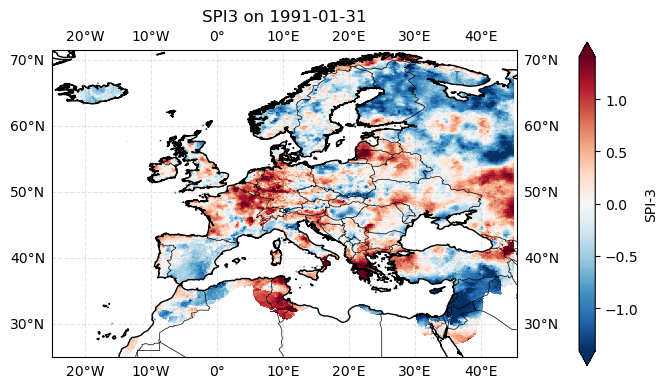

In [45]:
# Select SPI3 variable and first time step
da = ds_spi3['spo03'].isel(time=0)

fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection=ccrs.PlateCarree())

da.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',          # diverging colormap (good for wet/dry)
    robust=True,
    cbar_kwargs={'label': 'SPI-3', 'shrink' : 0.7, 'pad' : 0.1}
)
ax.coastlines(resolution='10m', linewidth=1)
ax.add_feature(ccrs.cartopy.feature.BORDERS, linewidth=0.5)
ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.2)

plt.title(f"SPI3 on {str(da['time'].values)[:10]}")
plt.show()

### SST — North Atlantic domain 

The red box on the SST map delineates the North Atlantic domain used for the
EOF decomposition (35–65°N, 70–10°W).

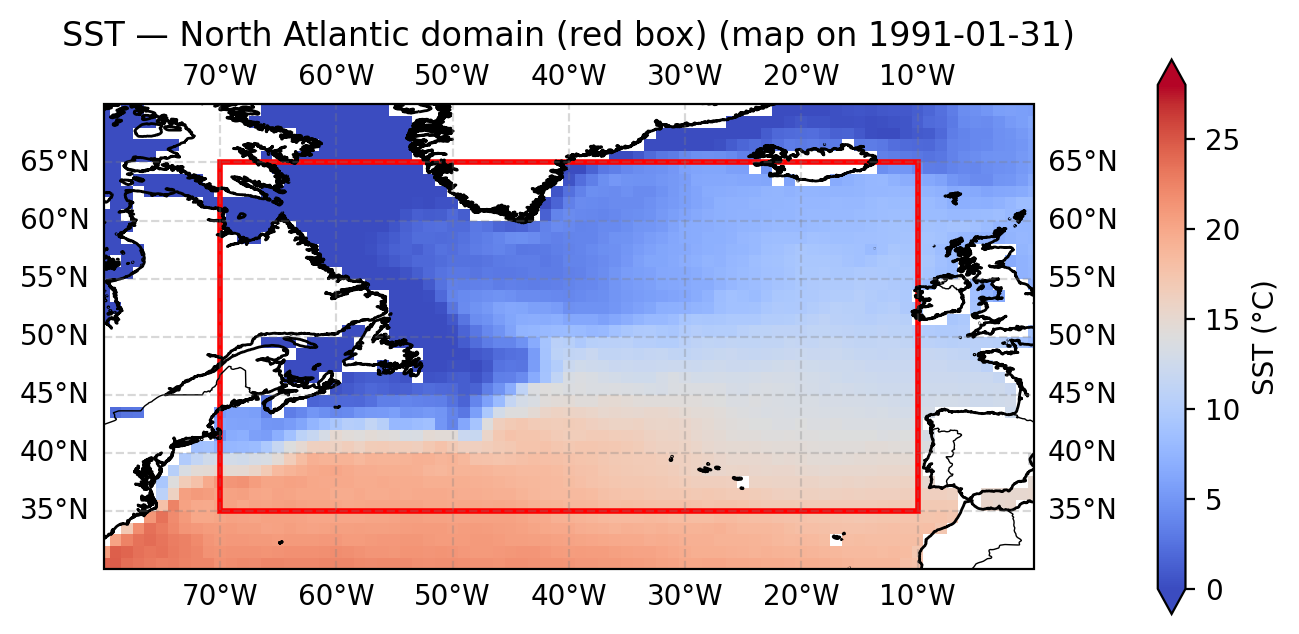

In [46]:
da = ds_sst['sst'].isel(time=0)

lat_min, lat_max = 35, 65
lon_min, lon_max = -70, -10

fig = plt.figure(figsize=(8, 6), dpi=200)
ax = plt.axes(projection=ccrs.PlateCarree())

da.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    robust=True,
    vmin=0, vmax=28,
    cbar_kwargs={'label': 'SST (°C)', 'shrink': 0.6, 'pad': 0.1}
)
ax.set_extent([-80, 0, 30, 70], crs=ccrs.PlateCarree())

rect = patches.Rectangle(
    (lon_min, lat_min), lon_max - lon_min, lat_max - lat_min,
    linewidth=2, edgecolor='red', facecolor='none',
    transform=ccrs.PlateCarree()
)
ax.add_patch(rect)

ax.coastlines(resolution='10m', linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.3)
plt.title(f'SST — North Atlantic domain (red box) (map on {str(da["time"].values)[:10]})')
plt.show()

## 1. Oceanic predictors — EOF analysis of North Atlantic SST

Following Chevuturi et al. (2025), we extract the leading modes of SST variability
separately for the **JFM** (January–March) and **JJA** (June–August) seasons, then
project the full monthly record onto those seasonal patterns to obtain continuous
predictor time series.

The EOF decomposition is performed on SST anomalies (monthly climatology removed)
with cosine-latitude weighting.

In [ ]:
# Climatology for anomalies (to take out seasonal cycles and focus on anomalies)
climatology = ds_sst.groupby('time.dayofyear').mean(dim='time', skipna=True) 

In [ ]:
anomaly = ds_sst.groupby('time.dayofyear') - climatology # Compute anomalies by removing the seasonal cycle
anomaly = anomaly.sel(lat=slice(35, 65),lon=slice(-70,-10)) # Only keep North Atlantic domain (red box)


### EOF spatial patterns

#### Annual EOF analysis

A complementary annual EOF decomposition provides the year-round PC1 and PC2
used as predictors in the regression models (Section 5).

In [ ]:
season = 'annual' # Can be 'annual' or 'seasonal' (if seasonal, would need to compute seasonal means first ; 
# however, seasonal means would reduce the number of time steps and thus the sample size for ML, so I kept it annual)
anomaly_seas= anomaly

#weighting by the square root of the cosine of latitude to account for convergence of meridians and get more balanced EOFs
coslat = np.cos(np.deg2rad(anomaly.coords['lat'].values)).clip(0., 1.) 
wgts = np.sqrt(coslat)[..., np.newaxis] 

anomaly_seas = anomaly_seas.dropna(dim="time", how="all")
solver = Eof(anomaly_seas['sst'], wgts)

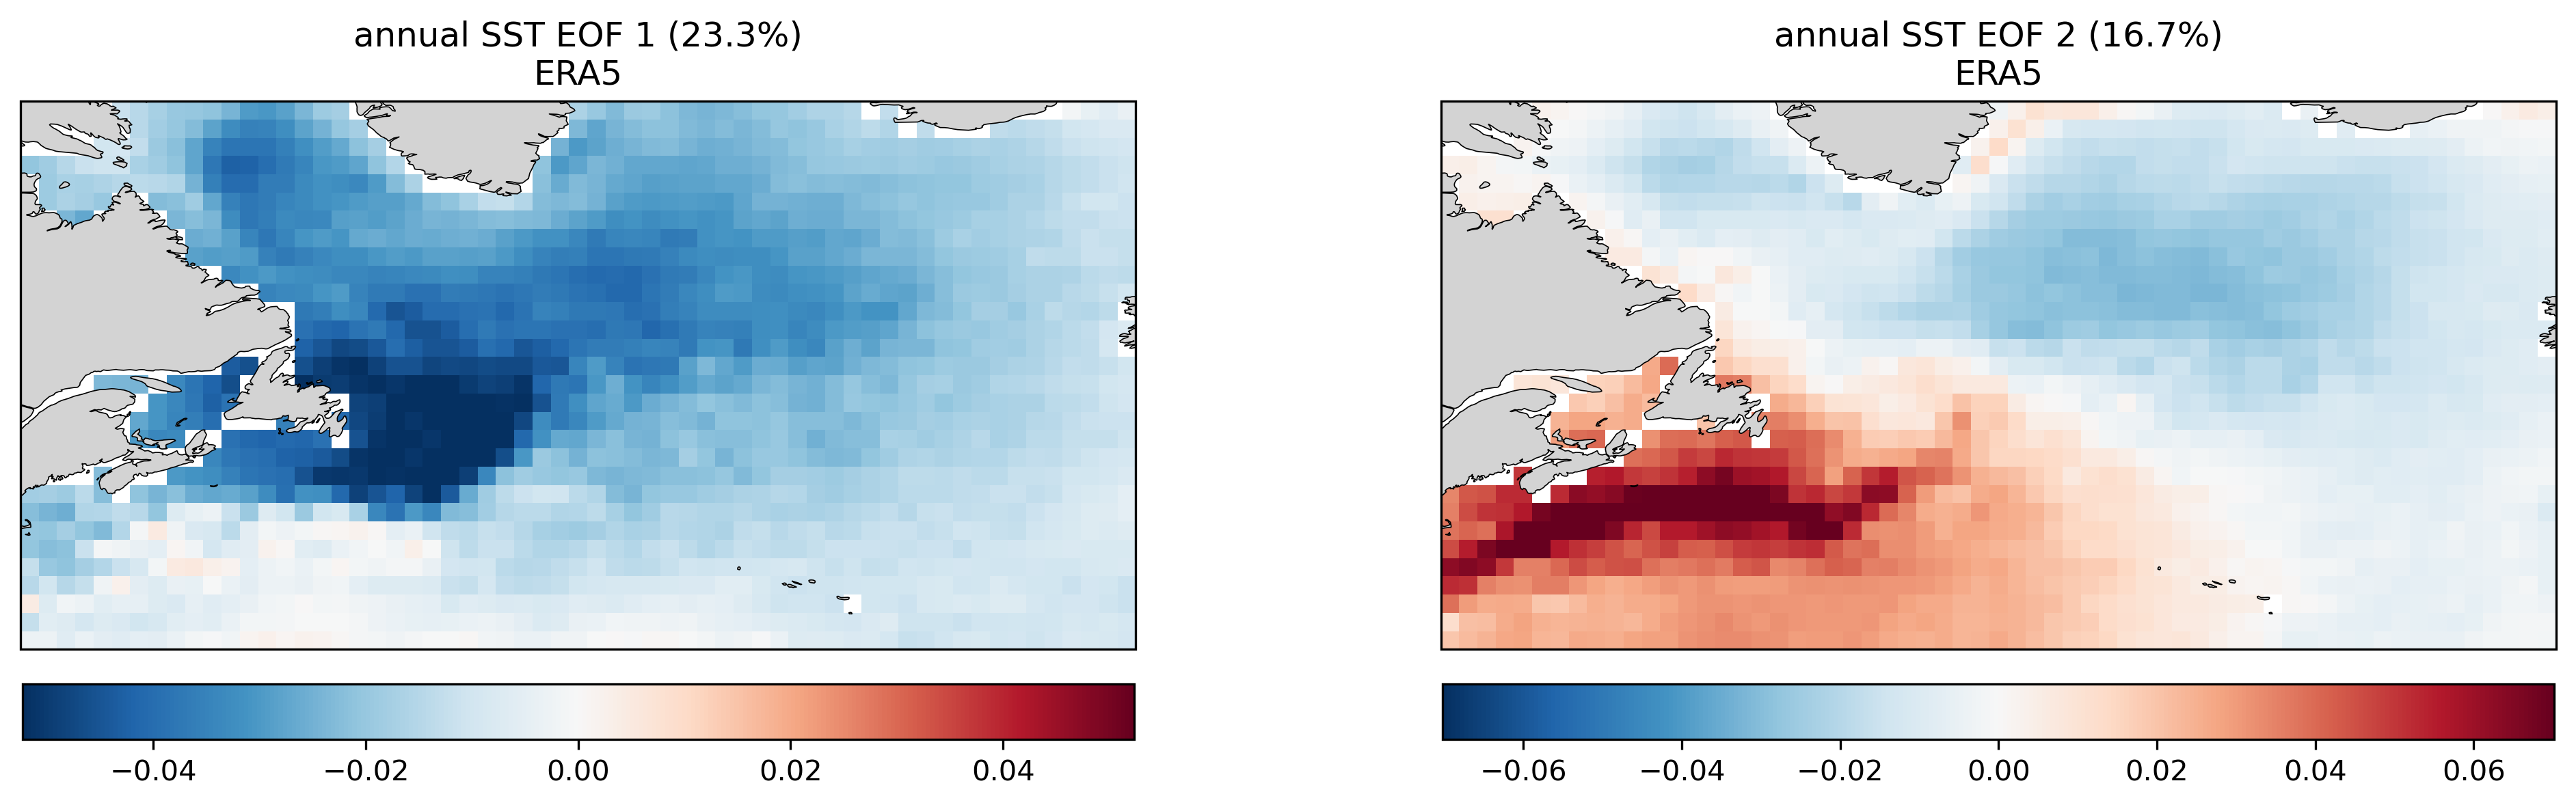

In [ ]:
eofs = solver.eofs(neofs=2)
pcs  = solver.pcs(npcs=2)
var  = solver.varianceFraction(neigs=10) * 100

lats  = anomaly['lat'].values
lons  = anomaly['lon'].values
lon2d, lat2d = np.meshgrid(lons, lats)

fig, axes = plt.subplots(1, 2, figsize=(14, 4),
                          subplot_kw={"projection": ccrs.PlateCarree()}, dpi=300)
for i, ax in enumerate(axes):
    v = np.nanpercentile(np.abs(eofs[i]), 98)
    pcm = ax.pcolormesh(lon2d, lat2d, eofs[i],
                        cmap="RdBu_r", vmin=-v, vmax=v, shading="auto")
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, zorder=2)
    ax.set_title(f"{season} SST EOF {i+1} ({var[i]:.1f}%)\n{SST_product}")
    plt.colorbar(pcm, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8)
fig.tight_layout()
#plt.savefig(f'{SST_product}-EOFs_{season}.png', dpi=300, bbox_inches='tight')

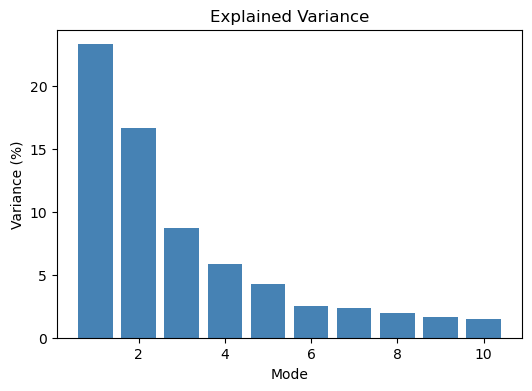

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(1, 11), var, color="steelblue")
ax.set(xlabel="Mode", ylabel="Variance (%)", title="Explained Variance")
plt.show()

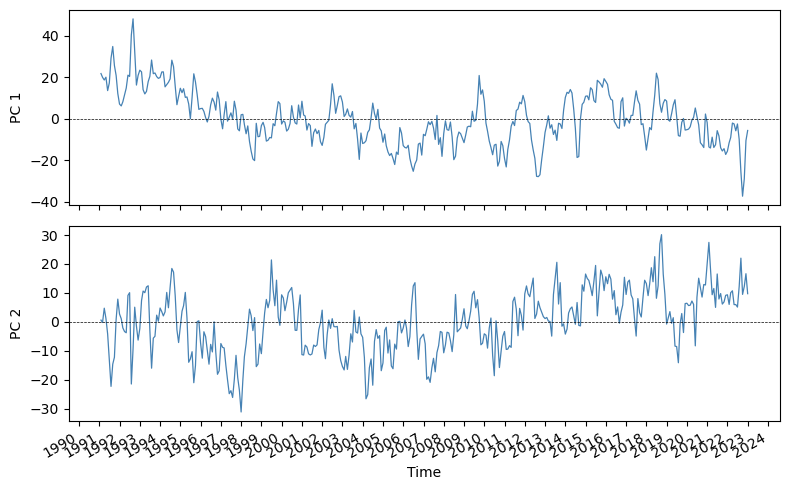

In [20]:
import matplotlib.dates as mdates

times = pd.to_datetime(anomaly_seas['time'].values)

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

for i, ax in enumerate(axes):
    ax.plot(times, pcs[:, i], lw=0.9, color="steelblue")
    ax.axhline(0, color="k", lw=0.5, ls="--")
    ax.set_ylabel(f"PC {i+1}")

axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[-1].set_xlabel("Time")
fig.autofmt_xdate()

fig.tight_layout()
plt.show()

In [21]:
PC1_year = pcs[:, 0]
PC2_year = pcs[:, 1]

## 2. Lagged correlations (map-level)

We compute the Pearson correlation between each SST PC and the European-mean SPI-3
as a function of lag $\tau$ (positive = SST leads SPI-3).
This gives a first indication of predictability and optimal lead time.

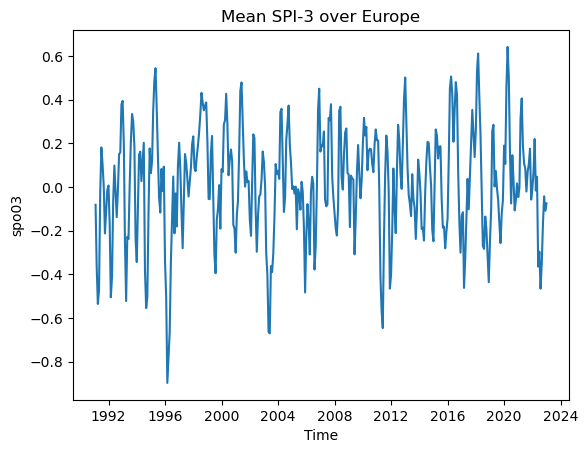

In [22]:
spi3_europe = ds_spi3['spo03']
spi3_europe_mean = spi3_europe.mean(dim=["lat", "lon"])
spi3_list = spi3_europe_mean.values.tolist()
SPI3_1d = [x[0] for x in spi3_list]  # Europe-mean SPI-3 time series

spi3_europe_mean.plot()
plt.title("Mean SPI-3 over Europe")
plt.xlabel("Time")
plt.show()

384 len spi3


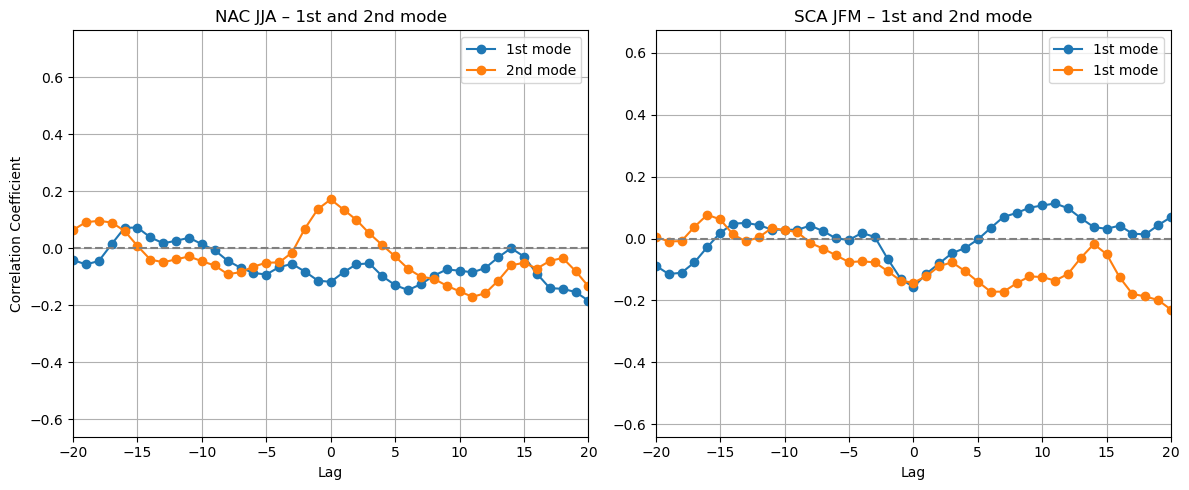

In [23]:


SPI3_1d_p = pd.Series(SPI3_1d)
print(len(SPI3_1d_p),"len spi3")


lags = range(-len(NAC_JJA_1st_p)+20, len(NAC_JJA_1st_p)-20)
correlations_NAC_JJA_1st = [NAC_JJA_1st_p .corr(SPI3_1d_p.shift(lag)) for lag in lags]
correlations_NAC_JJA_2nd = [NAC_JJA_2nd_p .corr(SPI3_1d_p.shift(lag)) for lag in lags]

correlations_SCA_JFM_1st = [SCA_JFM_1st_p .corr(SPI3_1d_p.shift(lag)) for lag in lags]
correlations_SCA_JFM_2nd = [SCA_JFM_2nd_p .corr(SPI3_1d_p.shift(lag)) for lag in lags]



fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=100)


axes[0].plot(lags, correlations_NAC_JJA_1st, marker='o', label='1st mode')
axes[0].plot(lags, correlations_NAC_JJA_2nd, marker='o', color='tab:orange', label='2nd mode')
axes[0].set_title('NAC JJA – 1st and 2nd mode')
axes[0].set_xlim(-20, 20)
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Correlation Coefficient')
axes[0].axhline(0, color='gray', linestyle='--')
axes[0].grid()
axes[0].legend()


axes[1].plot(lags, correlations_SCA_JFM_1st, marker='o', label='1st mode')
axes[1].plot(lags, correlations_SCA_JFM_2nd, marker='o', color='tab:orange', label='1st mode')
axes[1].set_title('SCA JFM – 1st and 2nd mode')
axes[1].set_xlim(-20, 20)
axes[1].set_xlabel('Lag')
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].grid()
axes[1].legend()

plt.tight_layout()
plt.show()


384 len spi3


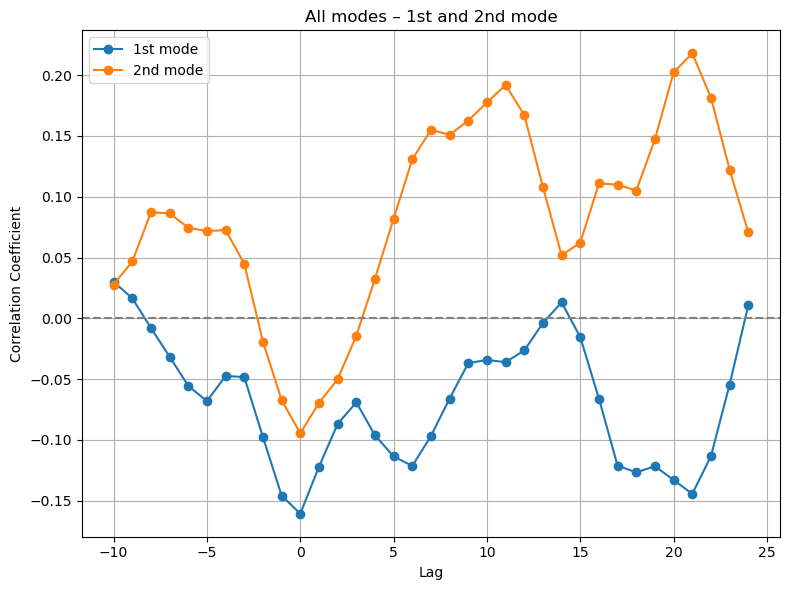

In [24]:
SPI3_1d_p = pd.Series(SPI3_1d)
print(len(SPI3_1d_p),"len spi3")

PC1_year_p = pd.Series(PC1_year)
PC2_year_p = pd.Series(PC2_year)


lags = range(-10, +25)
correlations_all_1st = [PC1_year_p.corr(SPI3_1d_p.shift(lag)) for lag in lags]
correlations_all_2nd = [PC2_year_p.corr(SPI3_1d_p.shift(lag)) for lag in lags]



plt.figure(figsize=(8,6),dpi=100)
plt.plot(lags, correlations_all_1st, marker='o', label='1st mode')
plt.plot(lags, correlations_all_2nd, marker='o', color='tab:orange', label='2nd mode')
plt.title('All modes – 1st and 2nd mode')
plt.xlabel('Lag')
plt.ylabel('Correlation Coefficient')
plt.axhline(0, color='gray', linestyle='--')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


## 3. $k$-means clustering of SPI-3

Rather than using a single Europe-wide index, we partition the SPI-3 spatial domain
into $k$ homogeneous regions using $k$-means clustering on the full time series
(one time series per grid point).

**Why $k=3$?** The choice of $k$ was guided by the silhouette score
(not reproduced here for brevity) and by consistency with the regional
structures reported by Chevuturi et al. (2025).

In [27]:
n_clusters = 3
stacked_spi3 = ds_spi3['spo03'].squeeze().stack(pixel=('lat', 'lon'))

from sklearn.impute import SimpleImputer

valid_pixel_mask = stacked_spi3.count(dim='time') > 0  # True = au moins une valeur

# Keep only land pixels (exclude permanent ocean NaNs)
stacked_land = stacked_spi3.where(valid_pixel_mask, drop=True)  
X_spi3_raw_land = stacked_land.transpose('pixel', 'time')

# Impute residual NaNs on land pixels (sparse missing dates)
imputer = SimpleImputer(strategy='mean')
X_spi3_imputed = imputer.fit_transform(X_spi3_raw_land.values)

kmeans = KMeans(n_clusters=n_clusters, n_init=10)
labels = kmeans.fit_predict(X_spi3_imputed)

# Rebuild geographic cluster mask
mask_geo = ds_spi3['spo03'].isel(time=0).copy()
mask_geo.values[:] = np.nan

pixel_coords = X_spi3_raw_land.pixel.values
for i, label in enumerate(labels):
    lat_i, lon_i = pixel_coords[i]
    mask_geo.loc[dict(lat=lat_i, lon=lon_i)] = label

Exception in thread Thread-6 (_readerthread):
Traceback (most recent call last):
  File "c:\python\envs\gfd_env\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "c:\python\envs\gfd_env\lib\threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "c:\python\envs\gfd_env\lib\subprocess.py", line 1515, in _readerthread
    buffer.append(fh.read())
  File "c:\python\envs\gfd_env\lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xae in position 13: invalid start byte


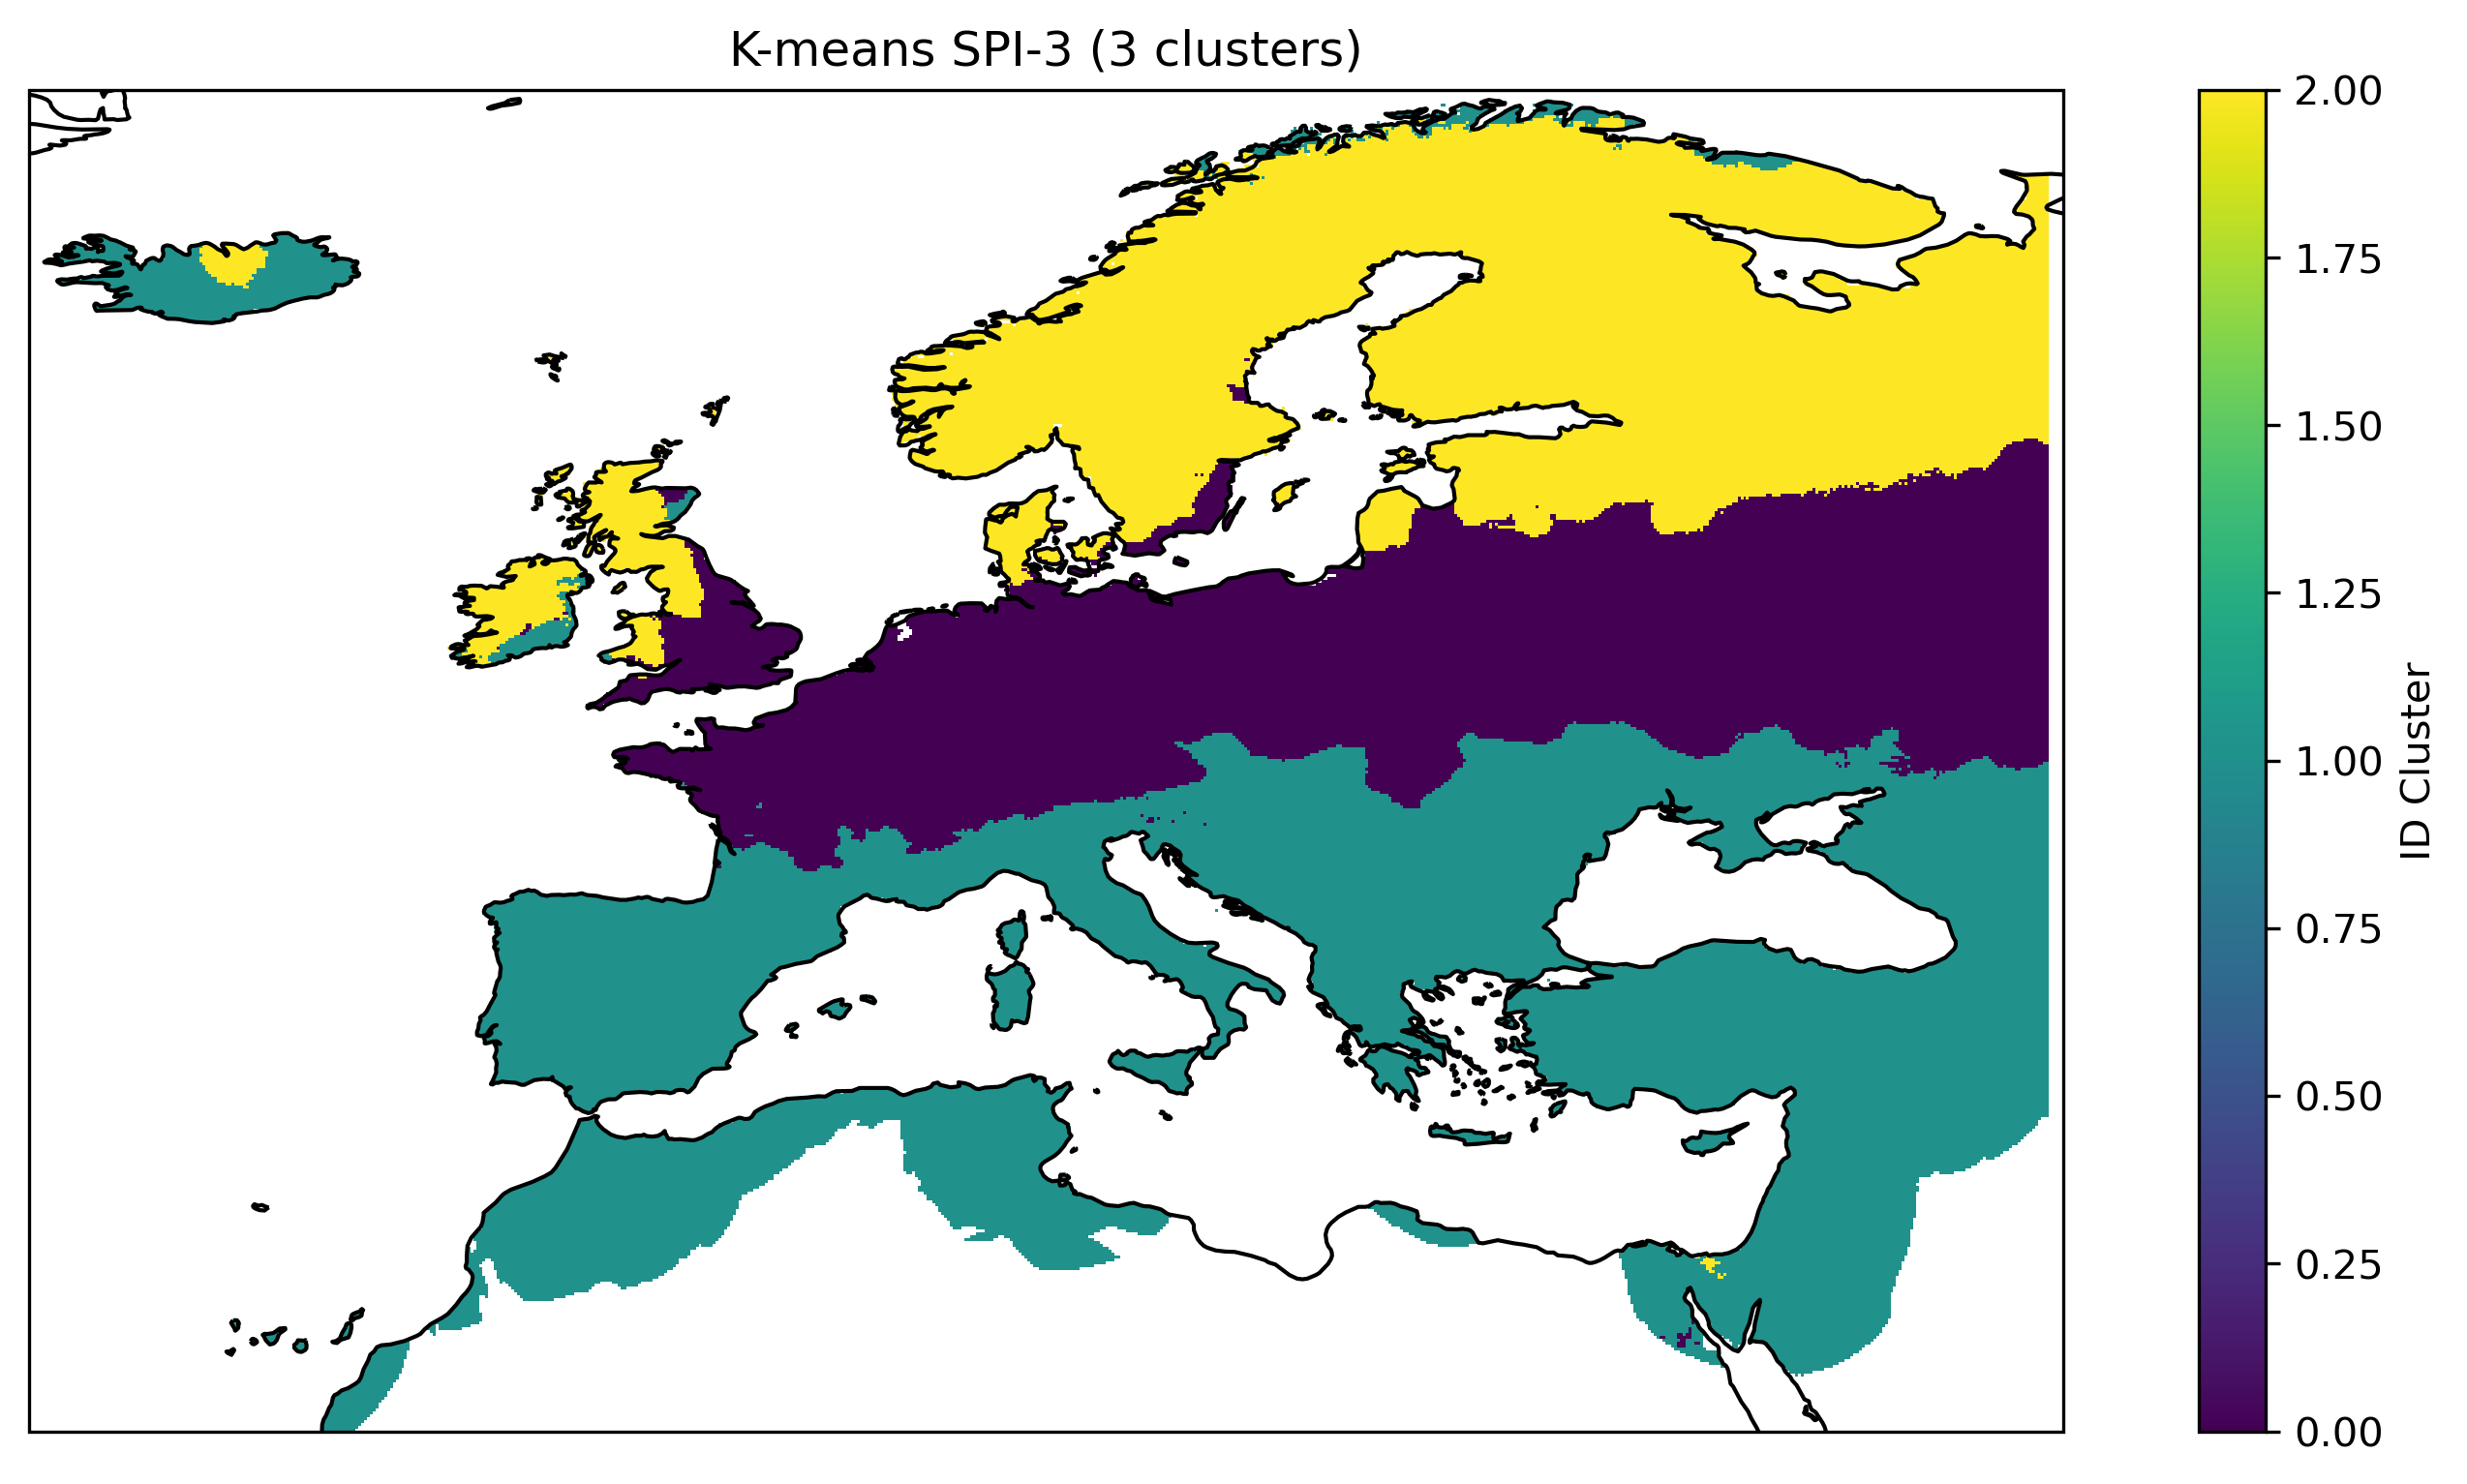

In [28]:
fig = plt.figure(figsize=(12, 6),dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())

im = mask_geo.plot(ax=ax, cmap='viridis', add_colorbar=True, 
                   cbar_kwargs={'label': 'ID Cluster'})
ax.coastlines()
ax.set_title(f'K-means SPI-3 ({n_clusters} clusters)')

plt.show()

## 4. Lagged correlations — regional time series

For each cluster, we compute the lead/lag correlation between the annual SST PCs
(PC1, PC2) and the cluster-mean SPI-3.
This step determines the **optimal lead time** $\tau^*$ used as input to the
predictive models in Section 5.

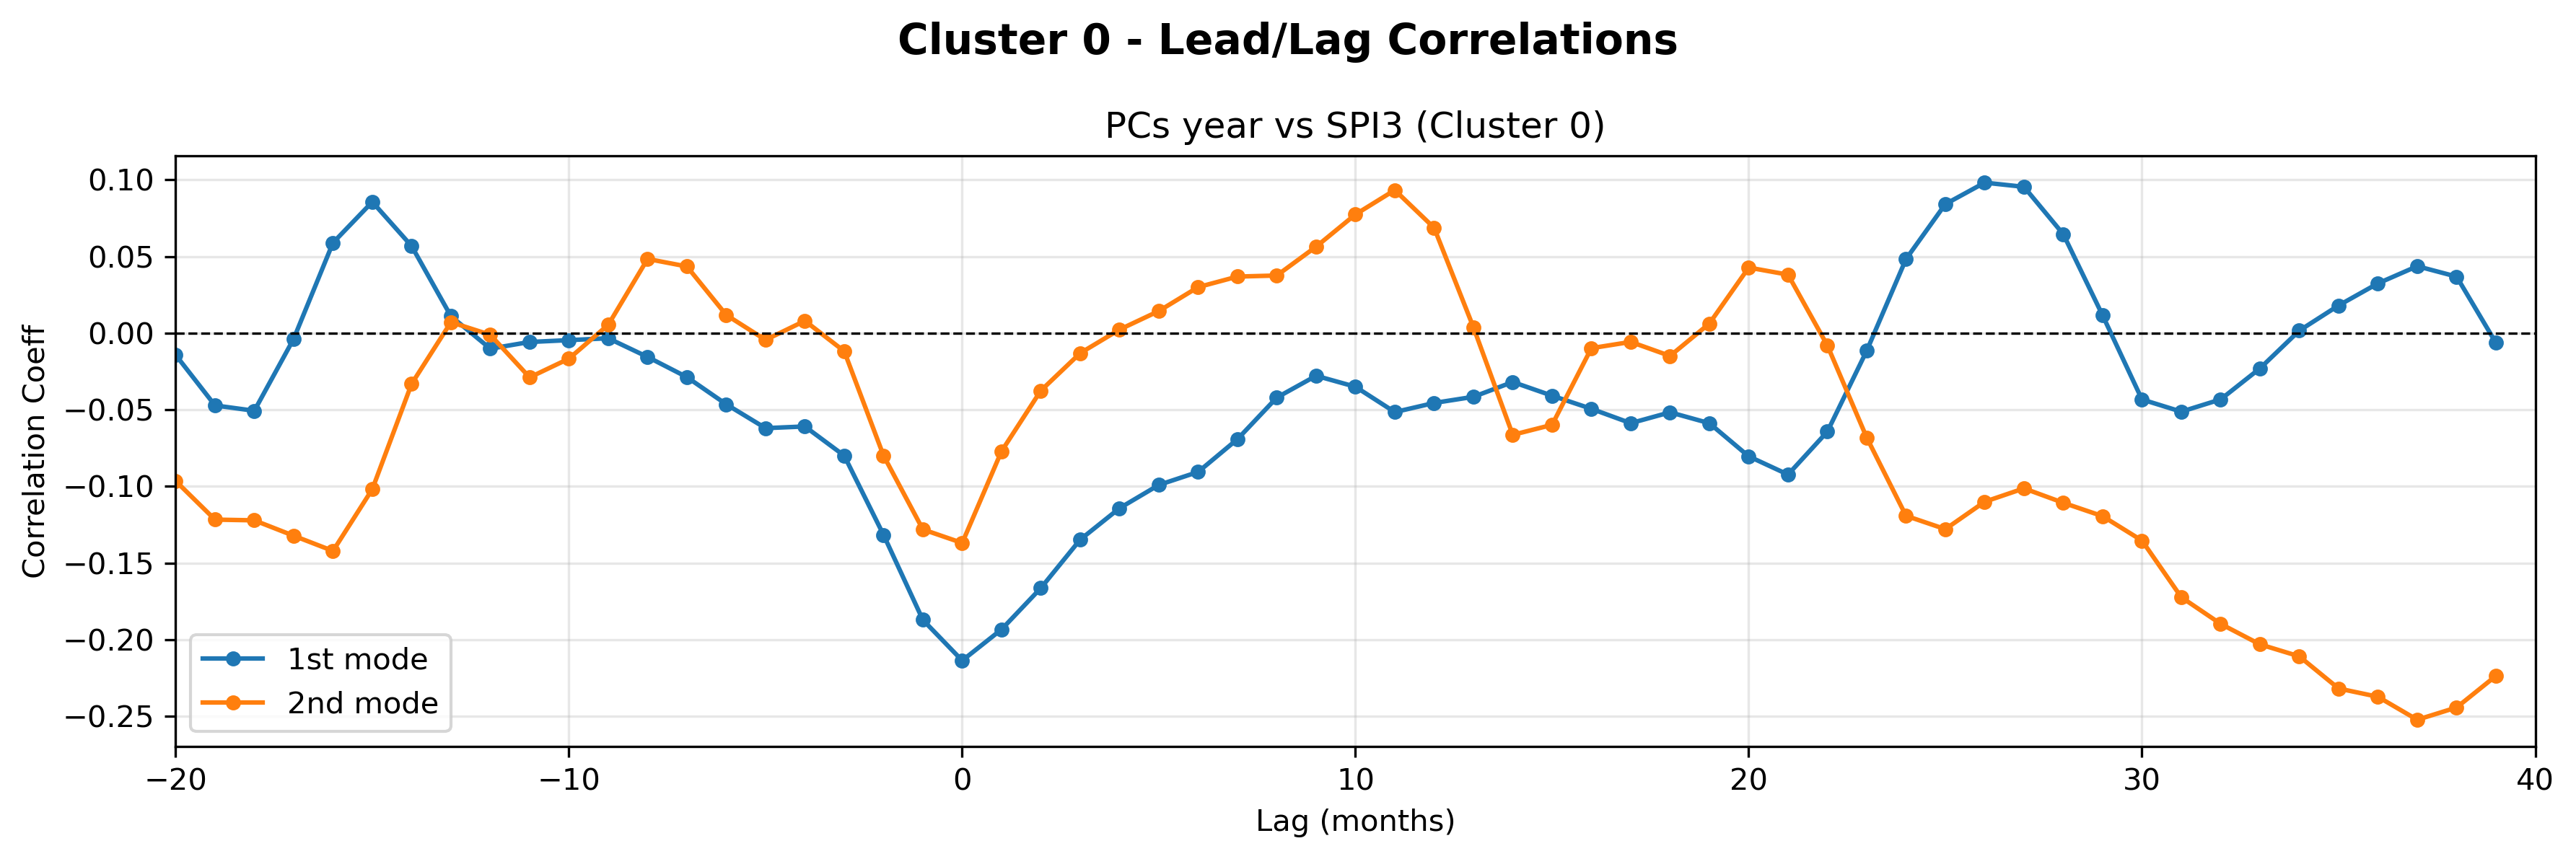

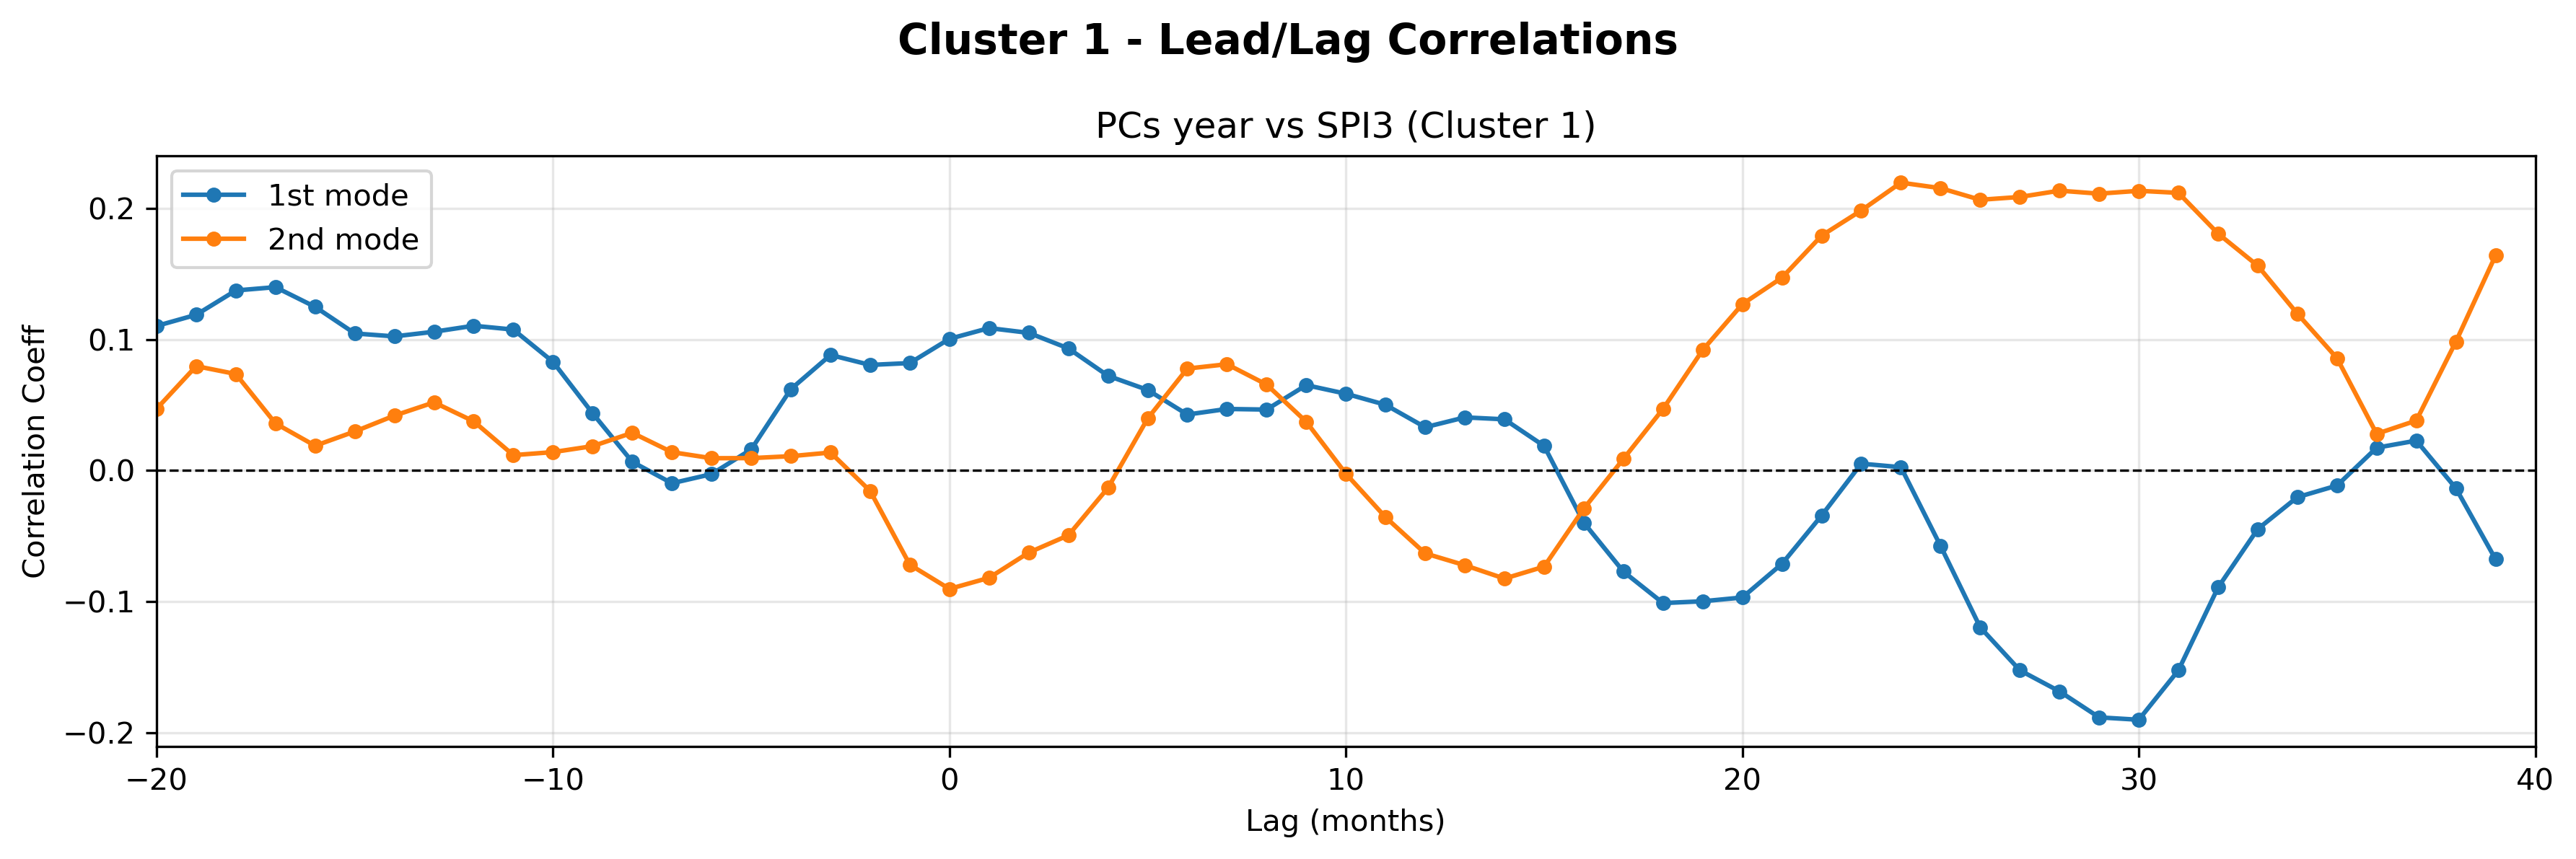

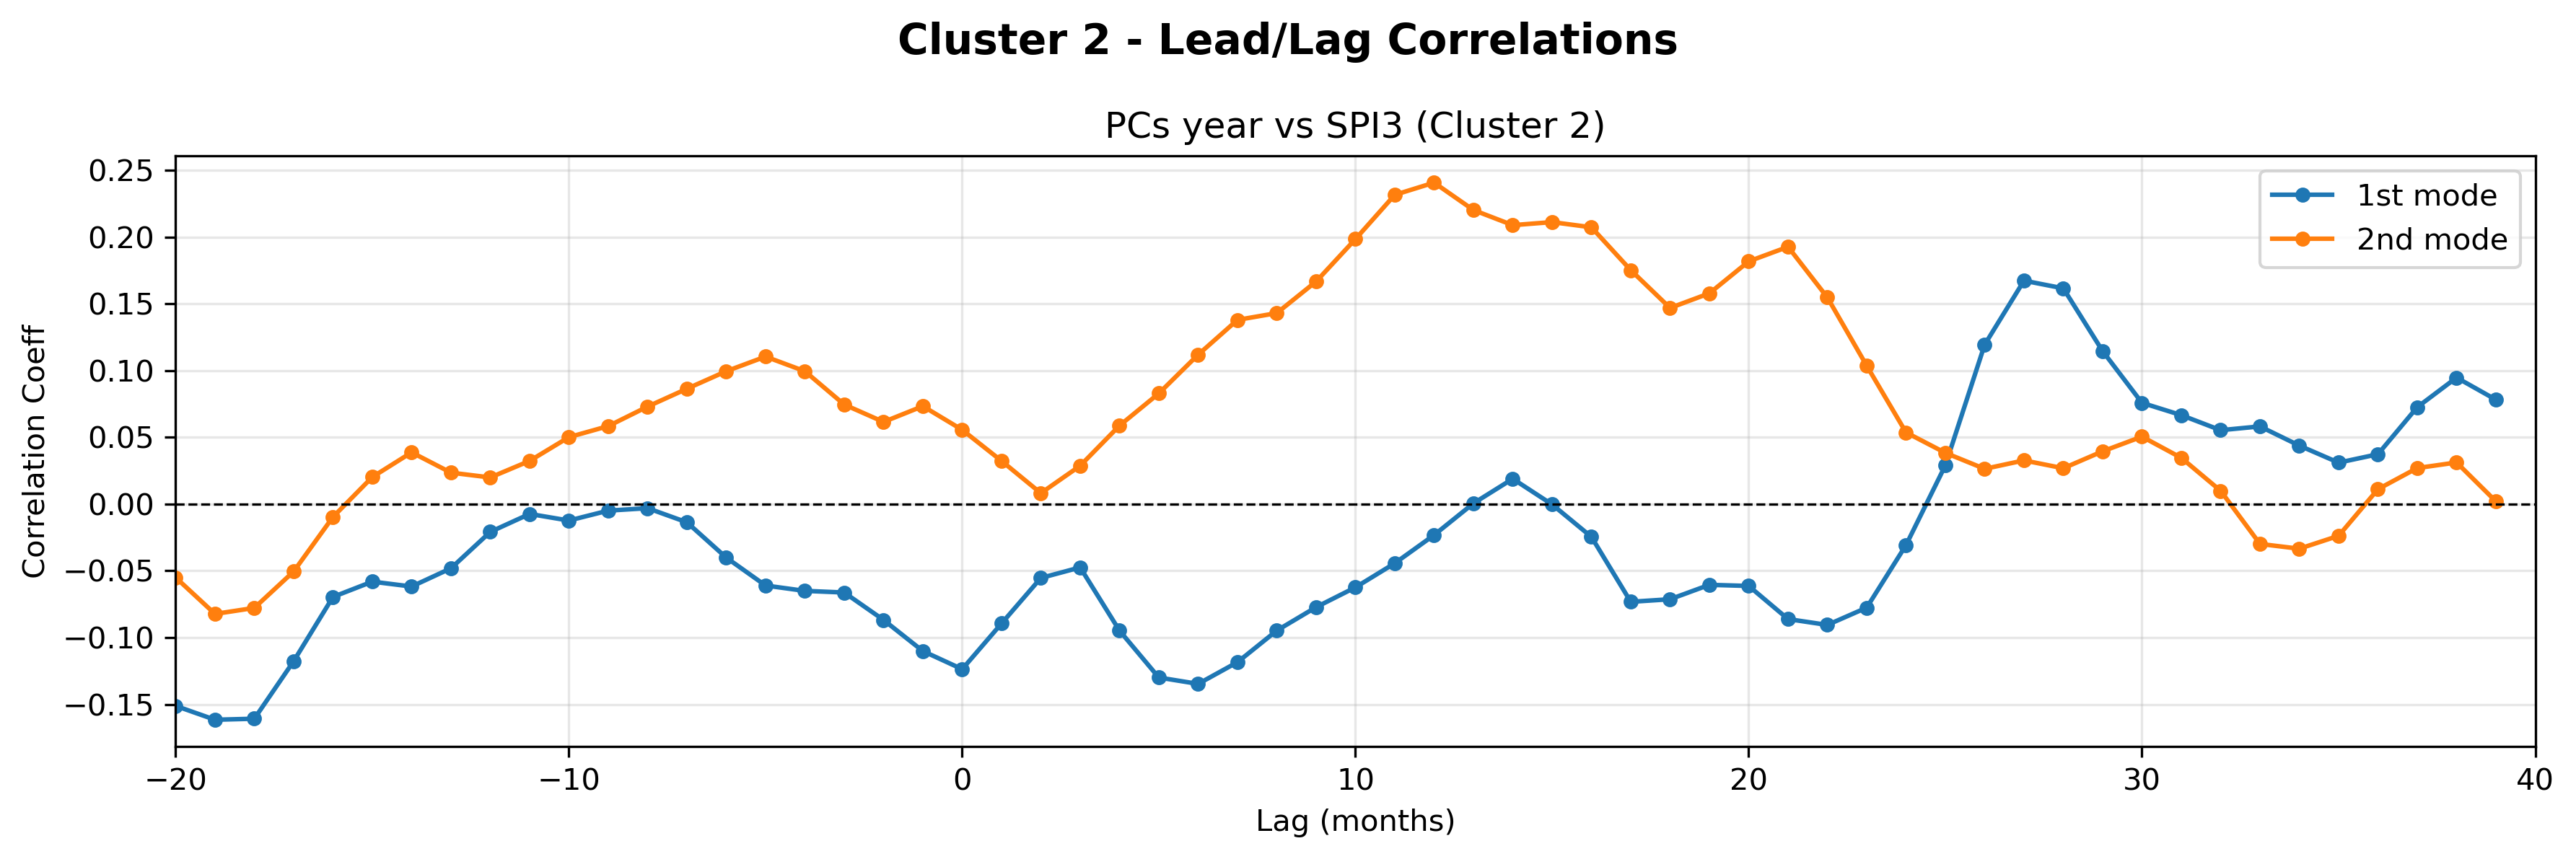

In [29]:

NAC_1_p = pd.Series(NAC_JJA_1st_cont).reset_index(drop=True)
NAC_2_p = pd.Series(NAC_JJA_2nd_cont).reset_index(drop=True)
SCA_1_p = pd.Series(SCA_JFM_1st_cont).reset_index(drop=True)
SCA_2_p = pd.Series(SCA_JFM_2nd_cont).reset_index(drop=True)



for cluster_id in range(n_clusters):
    
    mask_cluster = (mask_geo == cluster_id)
    spi3_cluster = ds_spi3['spo03'].where(mask_cluster)
    
    spi3_mean = spi3_cluster.mean(dim=["lat", "lon"])
    
    
    spi3_series = spi3_mean.to_series().reset_index(drop=True)
    

    lags = range(-20, 40) 
    
    corr_year_1 = [PC1_year_p.corr(spi3_series.shift(lag)) for lag in lags]
    corr_year_2 = [PC2_year_p.corr(spi3_series.shift(lag)) for lag in lags]

    plt.figure(figsize=(12, 4), dpi=300)
    plt.suptitle(f'Cluster {cluster_id} - Lead/Lag Correlations', fontsize=14, fontweight='bold')


    plt.plot(lags, corr_year_1, marker='o', markersize=4, label='1st mode')
    plt.plot(lags, corr_year_2, marker='o', markersize=4, color='tab:orange', label='2nd mode')
    plt.title(f'PCs year vs SPI3 (Cluster {cluster_id})')
    plt.xlim(-20, 40)
    plt.xlabel('Lag (months)')
    plt.ylabel('Correlation Coeff')
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

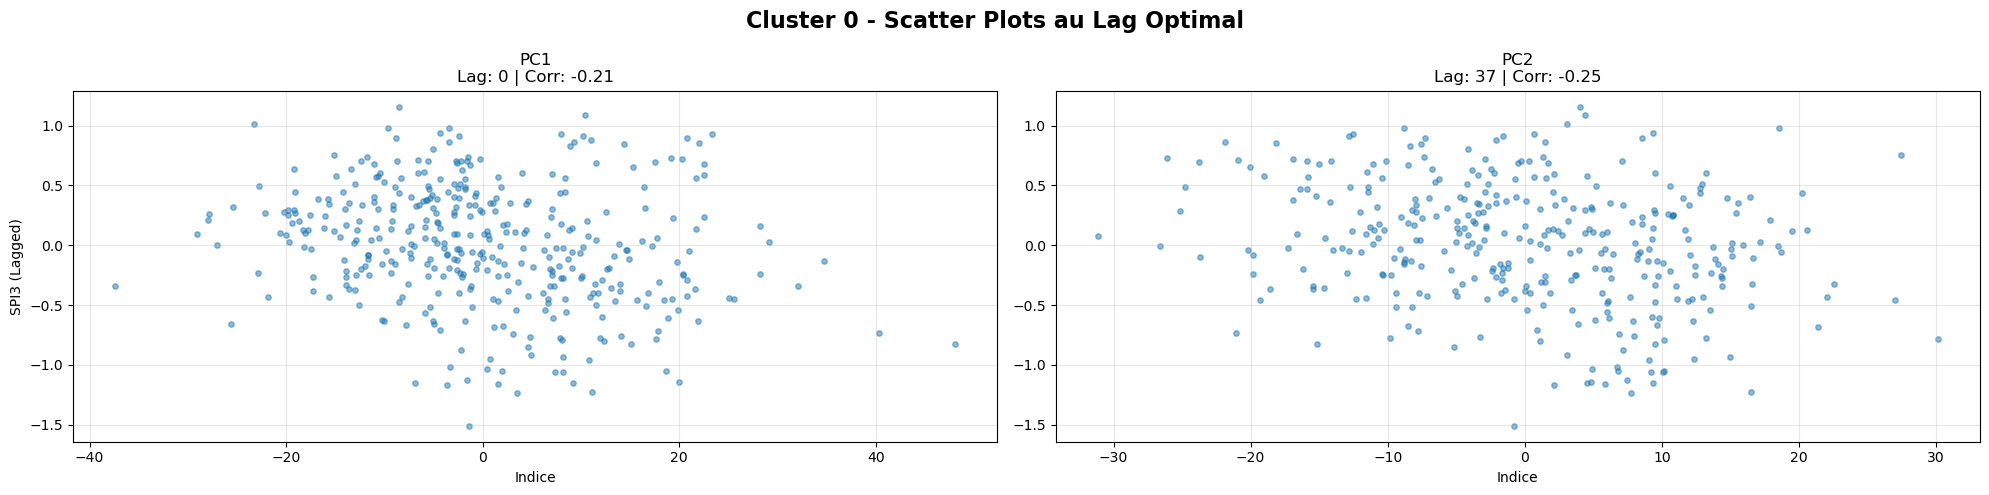

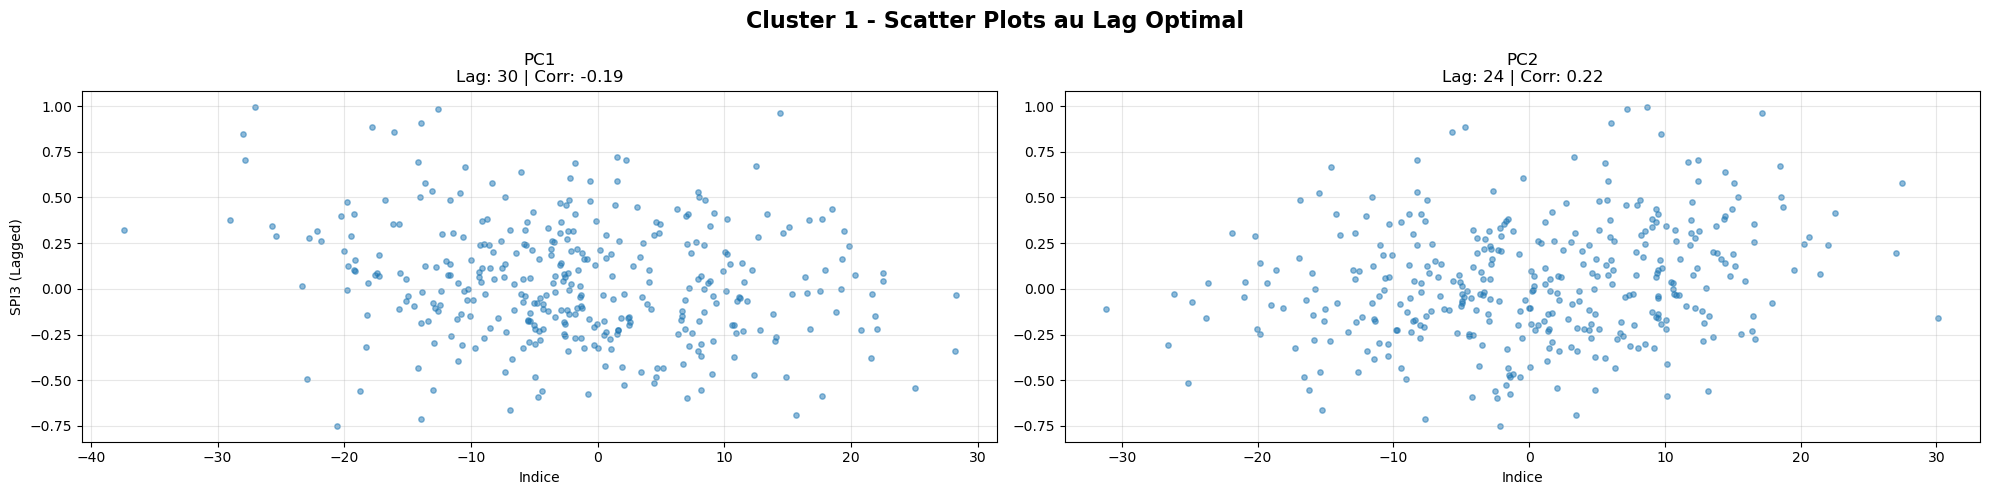

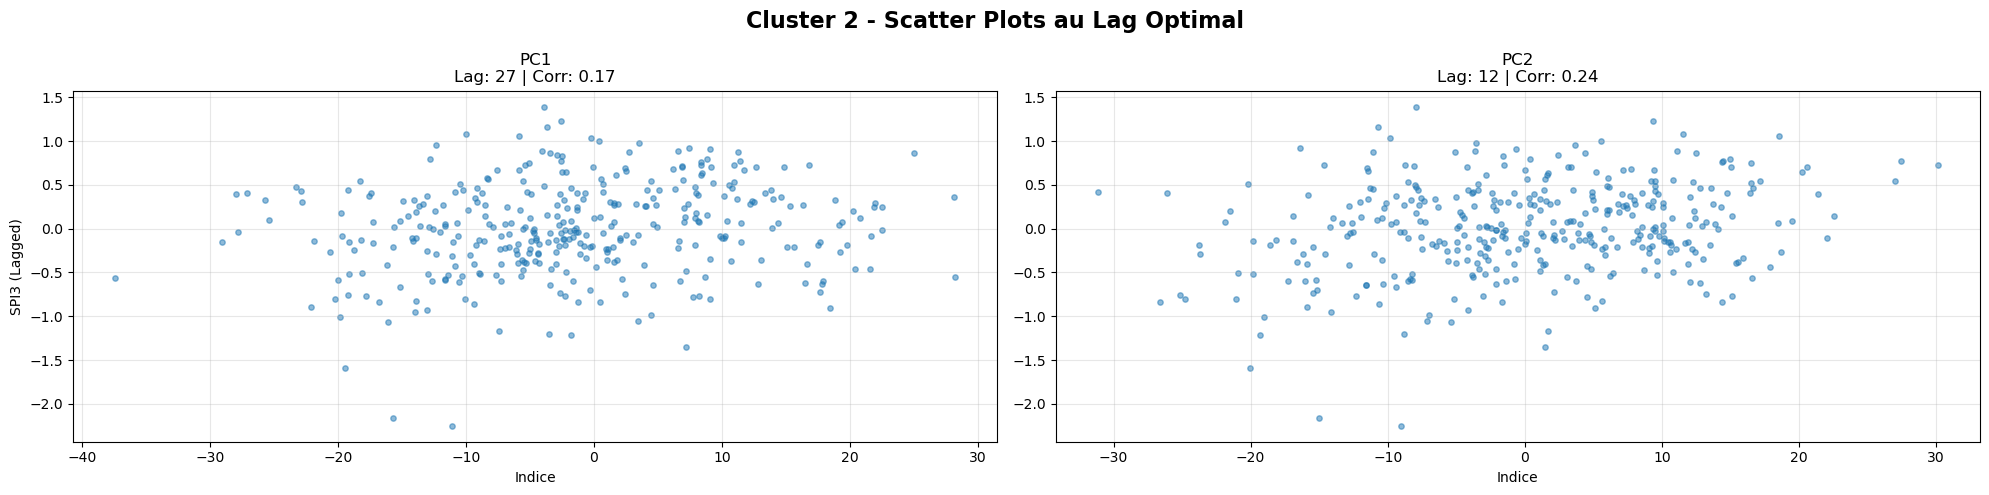

In [30]:

for cluster_id in range(n_clusters):
    
    mask_cluster = (mask_geo == cluster_id)
    spi3_cluster = ds_spi3['spo03'].where(mask_cluster)
    spi3_mean = spi3_cluster.mean(dim=["lat", "lon"])
    
    
    spi3_series = spi3_mean.to_series().reset_index(drop=True)
    

    lags = range(-10, 41) 
    
    corr_year_1 = [PC1_year_p.corr(spi3_series.shift(lag)) for lag in lags]
    corr_year_2 = [PC2_year_p.corr(spi3_series.shift(lag)) for lag in lags]


    results = [
        ("PC1", PC1_year_p, corr_year_1),
        ("PC2", PC2_year_p, corr_year_2)
    ]

 
    fig_scat, axes_scat = plt.subplots(1, 2, figsize=(20, 5), dpi=100)
    fig_scat.suptitle(f'Cluster {cluster_id} - Scatter Plots au Lag Optimal', fontsize=16, fontweight='bold')

    for i, (name, index_series, corr_list) in enumerate(results):
        # optimal lag
        abs_corr = [abs(c) for c in corr_list]
        max_idx = np.argmax(abs_corr)
        opt_lag = lags[max_idx]
        max_val = corr_list[max_idx]
        
        #  lag applied
        spi_lagged = spi3_series.shift(opt_lag)
        
        #print("len lagged spi",len(spi_lagged))
        
        ax = axes_scat[i]
        # remove nan if there are any
        mask_nan = index_series.notna() & spi_lagged.notna()
        ax.scatter(index_series[mask_nan], spi_lagged[mask_nan], alpha=0.5, s=15)
        
        #print(len(index_series[mask_nan]),len(spi_lagged[mask_nan]))

        ax.set_title(f"{name}\nLag: {opt_lag} | Corr: {max_val:.2f}")
        ax.set_xlabel("Indice")
        if i == 0: ax.set_ylabel("SPI3 (Lagged)")
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

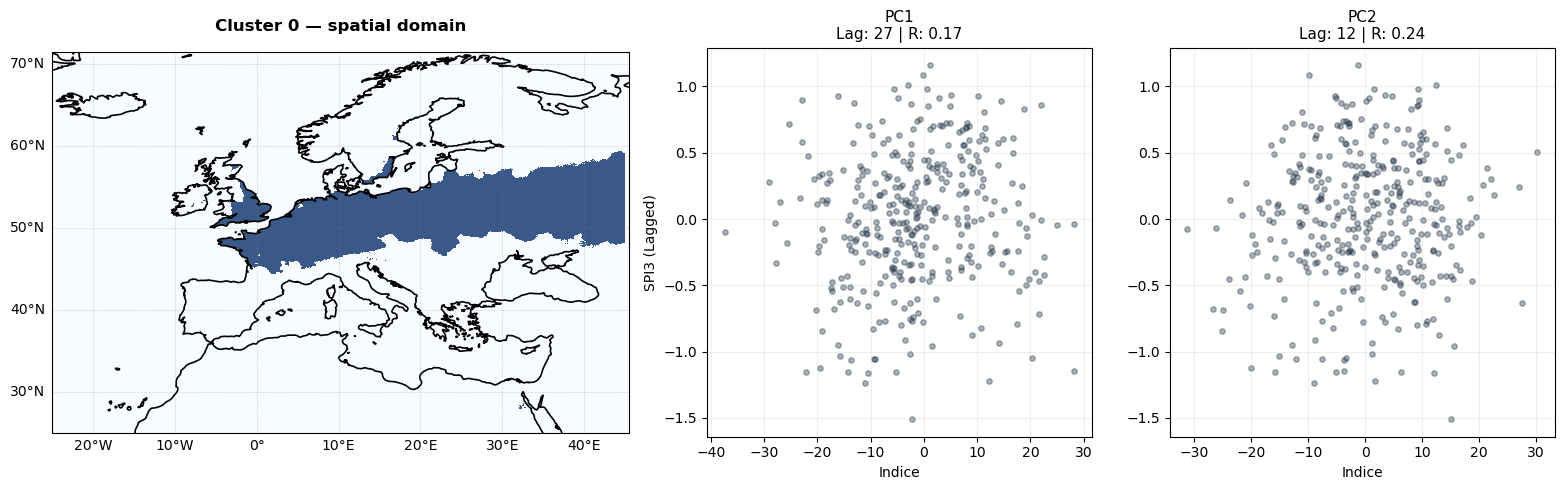

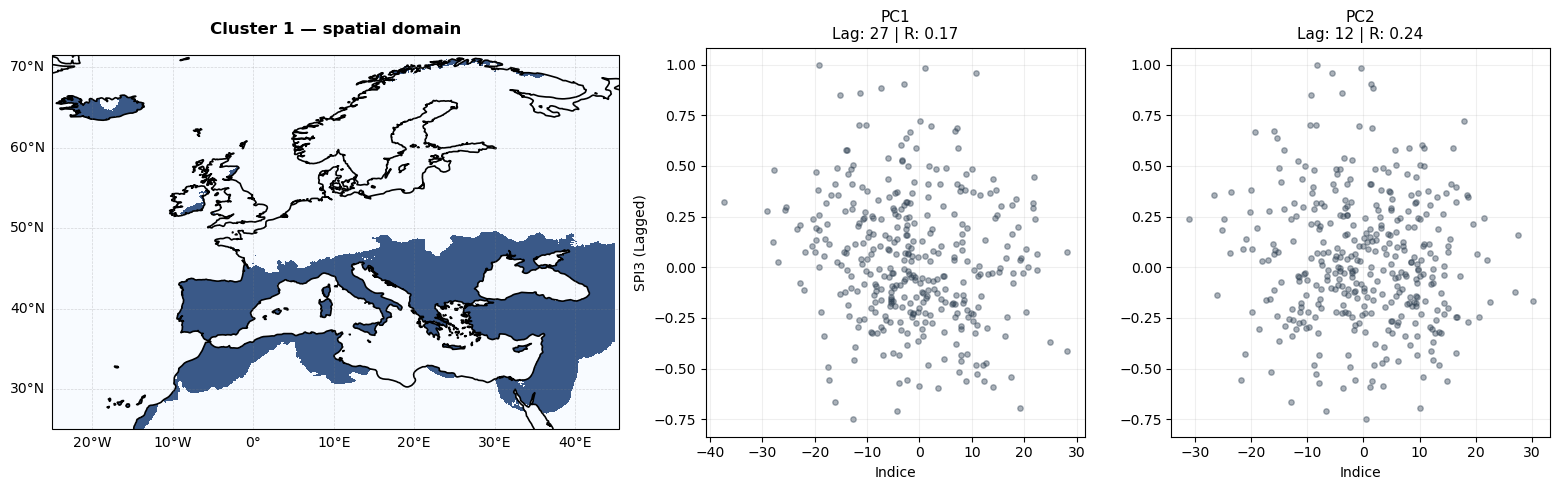

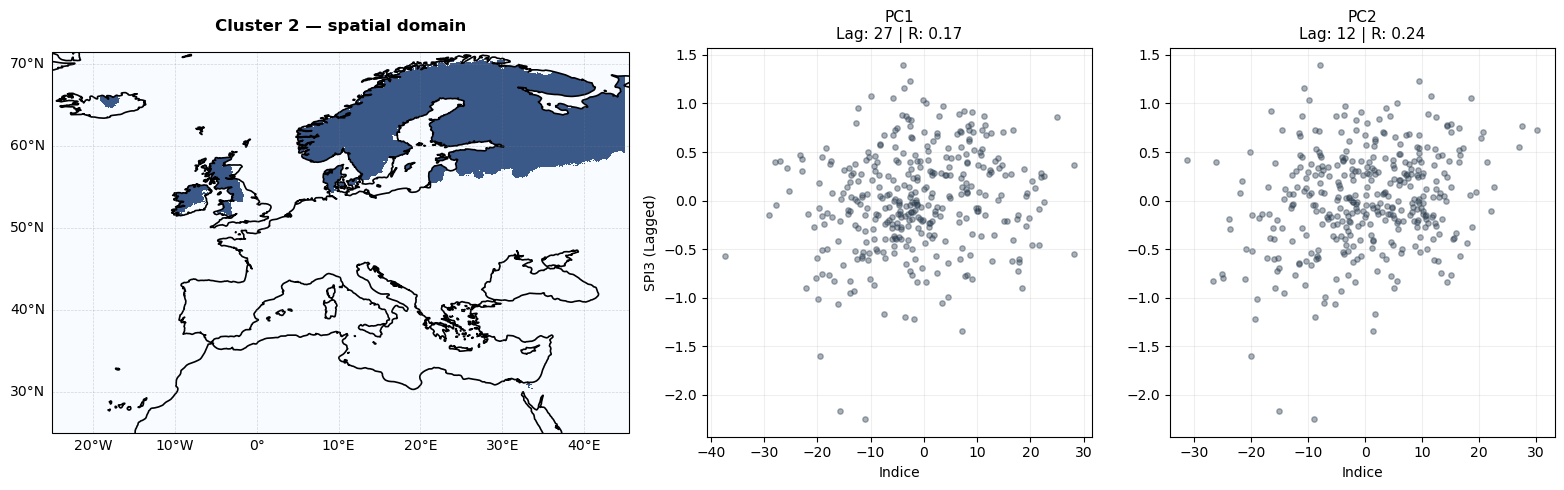

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


lags = range(-10, 41)
lons = ds_spi3.lon.values
lats = ds_spi3.lat.values

for cluster_id in range(n_clusters):
    
    mask_cluster = (mask_geo == cluster_id)
    spi3_cluster = ds_spi3['spo03'].where(mask_cluster)
    spi3_mean = spi3_cluster.mean(dim=["lat", "lon"])
    spi3_series = spi3_mean.to_series().reset_index(drop=True)


    fig = plt.figure(figsize=(25, 5), dpi=100)
    gs = plt.GridSpec(1, 5, width_ratios=[1.5, 1, 1, 1, 1])


    ax_map = fig.add_subplot(gs[0], projection=ccrs.PlateCarree())
    
    plot_data = mask_cluster.squeeze()
    

    im = ax_map.pcolormesh(lons, lats, plot_data, cmap='Blues', 
                           shading='auto', transform=ccrs.PlateCarree(), alpha=0.8)
    

    ax_map.coastlines(resolution='50m', color='black', linewidth=1.2, zorder=2)
    
    ax_map.set_title(f"Cluster {cluster_id} — spatial domain", fontweight='bold', pad=15)
    

    gl = ax_map.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.3, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False


    indices_data = [
        ("PC1", PC1_year_p, corr_year_1),
        ("PC2", PC2_year_p, corr_year_2)
    ]

    for i, (name, index_series, corr_list) in enumerate(indices_data):
        ax = fig.add_subplot(gs[i+1])
        

        abs_corr = [abs(c) for c in corr_list]
        max_idx = np.argmax(abs_corr)
        opt_lag = lags[max_idx]
        max_val = corr_list[max_idx]
        

        spi_lagged = spi3_series.shift(opt_lag)
        mask_valid = index_series.notna() & spi_lagged.notna()
        

        ax.scatter(index_series[mask_valid], spi_lagged[mask_valid], alpha=0.4, s=15, color='#2c3e50')
        

        ax.set_title(f"{name}\nLag: {opt_lag} | R: {max_val:.2f}", fontsize=11)
        ax.set_xlabel("Indice")
        if i == 0: ax.set_ylabel("SPI3 (Lagged)")
        ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

## 5. Predictive statistical model

For each SPI-3 cluster, we train two models using the annual SST PCs shifted
by the cluster-specific optimal lag $\tau^*$:

| Model | Parameters |
|-------|-----------|
| **ElasticNet** (linear) | $\alpha=0.1$, $l_1$-ratio $= 0.5$ |
| **MLP** (neural network) | 2 hidden layers $(16, 8)$, tanh, L2 $\alpha=0.5$ |

Chronological 80/20 train/test split. Statistical significance is assessed via
a **moving-block permutation test** (block size 3 months, 1 000 permutations)
to account for autocorrelation in the SPI-3 series (see autocorrelation plot below).

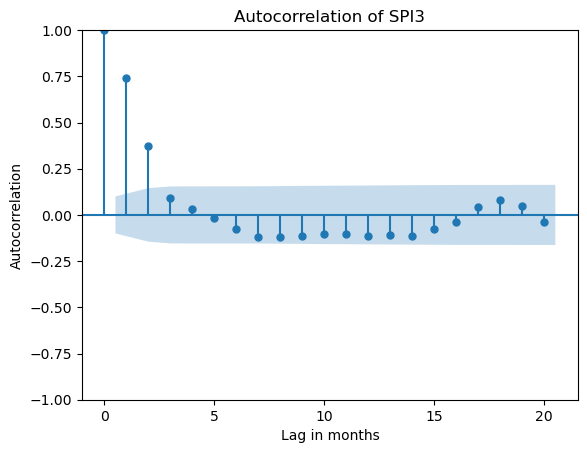

In [32]:
#check of autocorrelation on spi3
from statsmodels.graphics.tsaplots import plot_acf
spi3_series = ds_spi3['spo03'].mean(dim=["lat", "lon"]).to_series().reset_index(drop=True)
plot_acf(spi3_series.dropna(), lags=20)
plt.xlabel("Lag in months")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation of SPI3")
plt.show()

Cluster 0 - PC1_year optimal lag: 0 with corr: -0.21
Cluster 0 - PC2_year optimal lag: 37 with corr: -0.25
--- Cluster 0 ---
Mean RMSE: 0.473 (±0.050)
Mean bias: -0.008
Observed RMSE (LR): 0.4719
p-value (permutation, LR): 0.0030
Observed RMSE (NN): 0.4719
p-value (permutation, NN): 0.0020
Cluster 1 - PC1_year optimal lag: 30 with corr: -0.19
Cluster 1 - PC2_year optimal lag: 24 with corr: 0.22
--- Cluster 1 ---
Mean RMSE: 0.319 (±0.036)
Mean bias: -0.060
Observed RMSE (LR): 0.3245
p-value (permutation, LR): 0.0380
Observed RMSE (NN): 0.3216
p-value (permutation, NN): 0.0340
Cluster 2 - PC1_year optimal lag: 27 with corr: 0.17
Cluster 2 - PC2_year optimal lag: 12 with corr: 0.24
--- Cluster 2 ---
Mean RMSE: 0.471 (±0.043)
Mean bias: -0.062
Observed RMSE (LR): 0.4716
p-value (permutation, LR): 0.0170
Observed RMSE (NN): 0.5413
p-value (permutation, NN): 0.5620


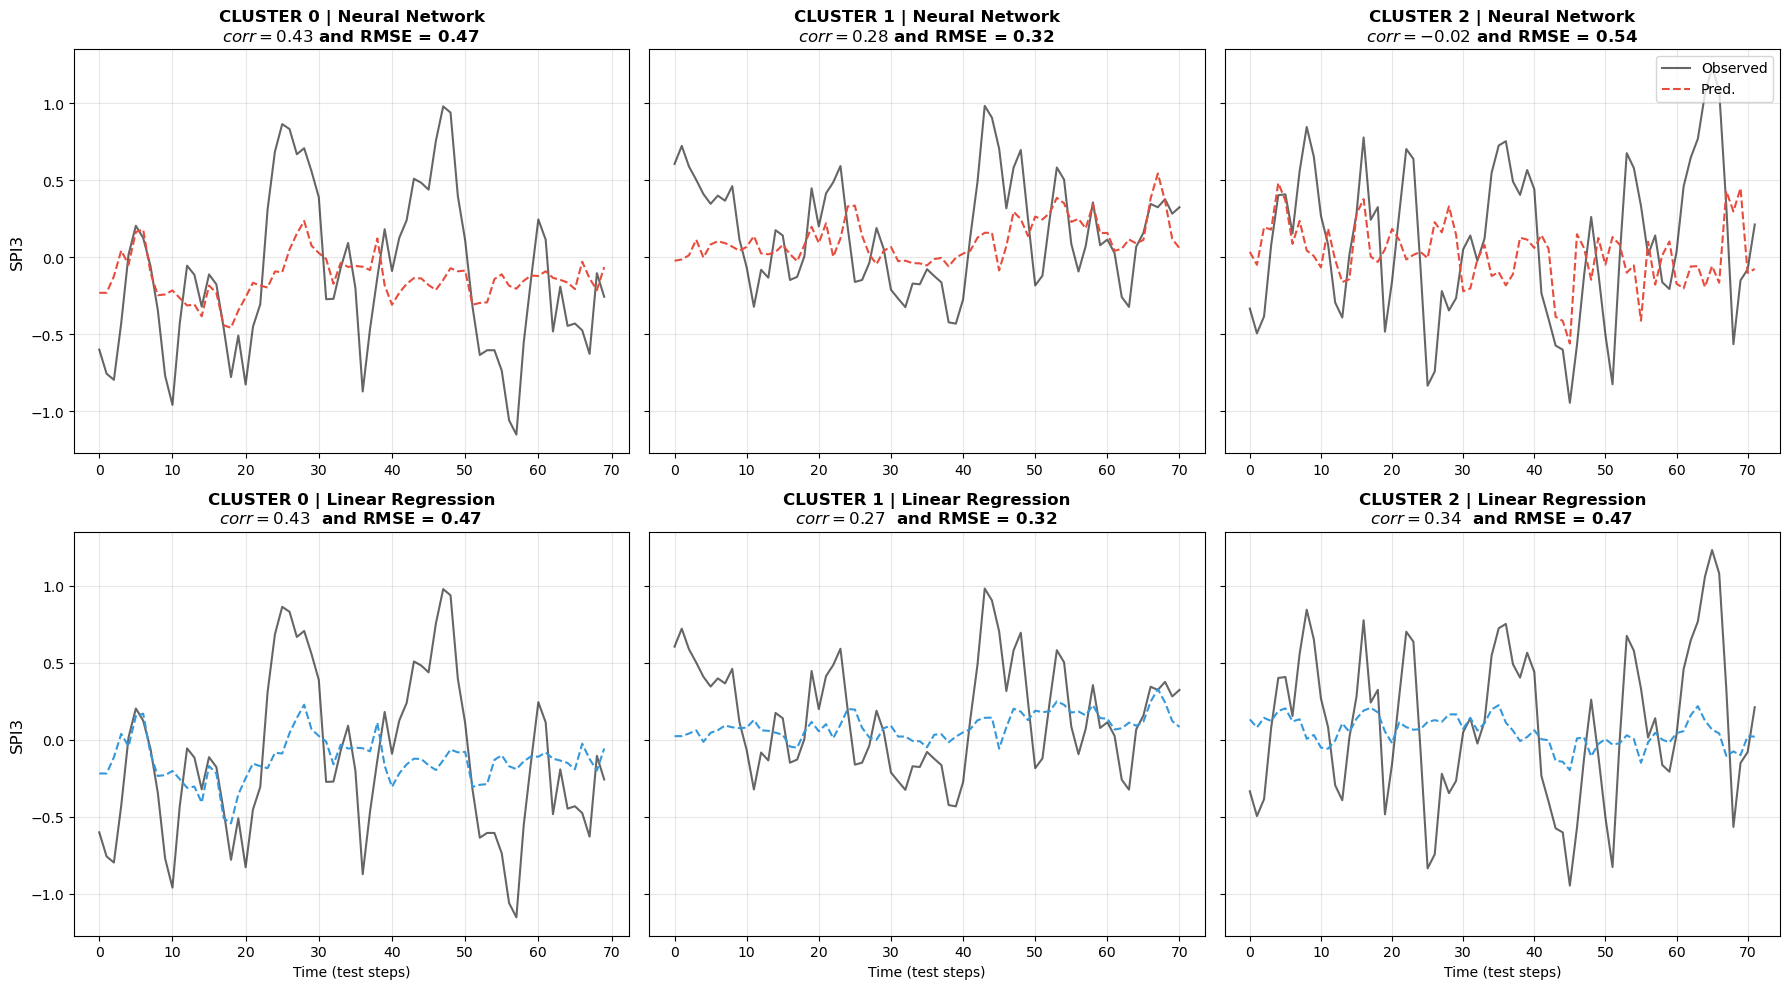

In [33]:
from sklearn.metrics import root_mean_squared_error, mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet

from arch.bootstrap import MovingBlockBootstrap
import numpy as np


fig, axes = plt.subplots(2, n_clusters, figsize=(18, 10), sharey=True)
train_split = 0.8

boot_corr_lr = []
real_corr_lr = []


p_value_lr = []
p_value_nn = []


for cluster_id in range(n_clusters):

    X_dict = {}
    mask_cluster = (mask_geo == cluster_id)
    y = ds_spi3['spo03'].where(mask_cluster).mean(dim=["lat", "lon"]).to_series().reset_index(drop=True)
    
    indices_list = [("PC1_year", PC1_year_p), ("PC2_year", PC2_year_p)]

    for name, series in indices_list:
        corrs = [series.corr(y.shift(lag)) for lag in lags]
        opt_lag = lags[np.argmax(np.abs(corrs))]
        print(f"Cluster {cluster_id} - {name} optimal lag: {opt_lag} with corr: {corrs[np.argmax(np.abs(corrs))]:.2f}")
        X_dict[f"{name}_lag{opt_lag}"] = series.shift(abs(opt_lag)) if opt_lag < 0 else series.shift(-opt_lag)
        #X_dict[f"{name}_lag{opt_lag}"] = series



    X = pd.DataFrame(X_dict)
    valid_idx = X.dropna().index.intersection(y.dropna().index)
    X_final = X.loc[valid_idx].values
    y_final = y.loc[valid_idx].values

    split = int(len(X_final) * train_split)
    X_train_raw, X_test_raw = X_final[:split], X_final[split:]
    y_train, y_test = y_final[:split], y_final[split:]


    scaler = StandardScaler()
    X_train_nn = scaler.fit_transform(X_train_raw)
    X_test_nn = scaler.transform(X_test_raw)
    
    model_nn = MLPRegressor(hidden_layer_sizes=(16,8),activation='tanh',alpha=0.5, max_iter=1000, random_state=42, solver='lbfgs')
    model_nn.fit(X_train_nn, y_train)
    y_pred_nn = model_nn.predict(X_test_nn)
    

    ax_nn = axes[0, cluster_id]
    ax_nn.plot(y_test, label="Observed", color='black', alpha=0.6, lw=1.5)
    ax_nn.plot(y_pred_nn, label="Pred.", color='#e74c3c', linestyle='--')
    ax_nn.set_title(f"CLUSTER {cluster_id} | Neural Network\n$corr = {np.corrcoef(y_test, y_pred_nn)[0, 1]:.2f}$ and RMSE = {root_mean_squared_error(y_test,y_pred_nn):.2f} ", fontweight='bold')
    ax_nn.grid(alpha=0.3)
    if cluster_id == 0: ax_nn.set_ylabel("SPI3", fontsize=12)


    model_lr = ElasticNet(alpha=0.1, l1_ratio=0.5)
    model_lr.fit(X_train_raw, y_train) 
    y_pred_lr = model_lr.predict(X_test_raw)

    


    
    boot_rmse = []
    boot_bias = []
    boot_corr = []

    bs = MovingBlockBootstrap(3, X_test_raw, y_test)
    
    for data in bs.bootstrap(1000):
        X_bs, y_bs = data[0]
        pred_bs = model_lr.predict(X_bs)
        
        
        boot_rmse.append(root_mean_squared_error(y_bs, pred_bs))
        boot_corr.append(np.corrcoef(y_bs, pred_bs)[0, 1])
        
        boot_bias.append(np.mean(pred_bs) - np.mean(y_bs))



    mean_rmse = np.mean(boot_rmse)
    std_error_rmse = np.std(boot_rmse) 
    avg_bias = np.mean(boot_bias)      

    print(f"--- Cluster {cluster_id} ---")
    print(f"Mean RMSE: {mean_rmse:.3f} (±{std_error_rmse:.3f})")
    print(f"Mean bias: {avg_bias:.3f}") 
    
    boot_corr_lr.append(boot_corr)




    
    # H0 : model doesn't predict better than random
    observed_rmse_lr = root_mean_squared_error(y_test, model_lr.predict(X_test_raw))
    observed_rmse_nn = root_mean_squared_error(y_test, model_nn.predict(X_test_nn))

    # null distribution by shuffling y_test
    null_rmse_lr = []
    null_rmse_nn = []
    rng = np.random.default_rng(42)

    limit = (len(y_test) // 3) * 3
    for _ in range(1000):
        #y_shuffled = rng.permutation(y_test)
        y_shuffled = rng.permutation(y_test[:limit].reshape(-1, 3)).ravel()
        null_rmse_lr.append(root_mean_squared_error(y_shuffled, model_lr.predict(X_test_raw[:limit])))
        null_rmse_nn.append(root_mean_squared_error(y_shuffled, model_nn.predict(X_test_nn[:limit])))

    p_value_lr.append(np.mean(np.array(null_rmse_lr) <= observed_rmse_lr))
    print(f"Observed RMSE (LR): {observed_rmse_lr:.4f}")
    print(f"p-value (permutation, LR): {p_value_lr[-1]:.4f}")

    p_value_nn.append(np.mean(np.array(null_rmse_nn) <= observed_rmse_nn))
    print(f"Observed RMSE (NN): {observed_rmse_nn:.4f}")
    print(f"p-value (permutation, NN): {p_value_nn[-1]:.4f}")






    ax_lr = axes[1, cluster_id]
    ax_lr.plot(y_test, label="Observed", color='black', alpha=0.6, lw=1.5)
    ax_lr.plot(y_pred_lr, label="Pred.", color='#3498db', linestyle='--')
    ax_lr.set_title(f"CLUSTER {cluster_id} | Linear Regression\n$corr = {np.corrcoef(y_test, y_pred_lr)[0, 1]:.2f}$  and RMSE = {root_mean_squared_error(y_test,y_pred_lr):.2f} ", fontweight='bold')
    ax_lr.grid(alpha=0.3)
    if cluster_id == 0: ax_lr.set_ylabel("SPI3", fontsize=12)
    ax_lr.set_xlabel("Time (test steps)")

    real_corr_lr.append(np.corrcoef(y_test, y_pred_lr)[0, 1])


axes[0, 2].legend(loc='upper right')
plt.tight_layout()
plt.show()

### Hyperparameter selection — neural network

Grid search over hidden-layer sizes and regularisation strength using
time-series cross-validation (5 folds, `TimeSeriesSplit`).

In [34]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

tscv = TimeSeriesSplit(n_splits=5)
param_grid = {'hidden_layer_sizes': [(8,), (16, 8), (32,)], 
              'alpha': [0.001, 0.01, 0.1]}
gs = GridSearchCV(MLPRegressor(max_iter=1000, early_stopping=True), 
                  param_grid, cv=tscv, scoring='r2')
gs.fit(X_train_nn, y_train)

c:\python\envs\gfd_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,estimator,MLPRegressor(...max_iter=1000)
,param_grid,"{'alpha': [0.001, 0.01, ...], 'hidden_layer_sizes': [(8,), (16, ...), ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [35]:
print("Meilleurs params :", gs.best_params_)
print("Meilleur R² en CV :", gs.best_score_)

best_model = gs.best_estimator_

y_pred = best_model.predict(X_test_nn)

print("R² test :", r2_score(y_test, y_pred))
print("Corrélation :", np.corrcoef(y_pred, y_test)[0, 1])


results = pd.DataFrame(gs.cv_results_)
print(results[['param_hidden_layer_sizes', 'param_alpha', 
               'mean_test_score', 'std_test_score']].sort_values('mean_test_score', ascending=False))

Meilleurs params : {'alpha': 0.01, 'hidden_layer_sizes': (16, 8)}
Meilleur R² en CV : -0.11197965145111084
R² test : 0.050103187561035156
Corrélation : 0.2563660486368792
  param_hidden_layer_sizes  param_alpha  mean_test_score  std_test_score
4                  (16, 8)        0.010        -0.111980        0.111760
7                  (16, 8)        0.100        -0.144730        0.211539
8                    (32,)        0.100        -0.158105        0.152089
6                     (8,)        0.100        -0.175490        0.180861
3                     (8,)        0.010        -0.218557        0.178264
5                    (32,)        0.010        -0.224390        0.208544
2                    (32,)        0.001        -0.293190        0.116735
1                  (16, 8)        0.001        -0.293224        0.581098
0                     (8,)        0.001        -0.327862        0.206139


### Significance — bootstrapped correlation distributions

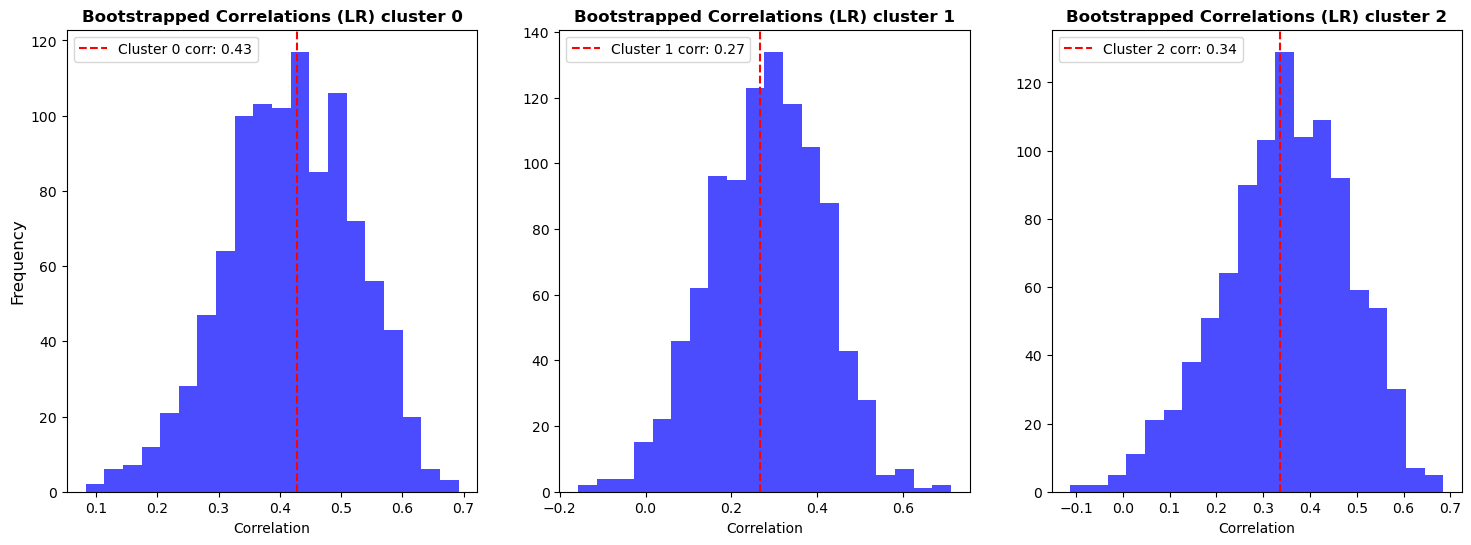

In [36]:
#significance test for correlation coefficients

fig, axes = plt.subplots(1,n_clusters, figsize=(18, 6), sharey=False)

axes[0].set_ylabel("Frequency", fontsize=12)
axes[0].set_title("Bootstrapped Correlations (LR) cluster 0", fontweight='bold')
axes[0].axvline(real_corr_lr[0], color='r', linestyle='--', label=f'Cluster 0 corr: {real_corr_lr[0]:.2f}')
axes[0].hist(boot_corr_lr[0], bins=20, color='b', alpha=0.7)

axes[1].set_title("Bootstrapped Correlations (LR) cluster 1", fontweight='bold')
axes[1].axvline(real_corr_lr[1], color='r', linestyle='--', label=f'Cluster 1 corr: {real_corr_lr[1]:.2f}')
axes[1].hist(boot_corr_lr[1], bins=20, color='b', alpha=0.7)


axes[2].set_title("Bootstrapped Correlations (LR) cluster 2", fontweight='bold')
axes[2].axvline(real_corr_lr[2], color='r', linestyle='--', label=f'Cluster 2 corr: {real_corr_lr[2]:.2f}')
axes[2].hist(boot_corr_lr[2], bins=20, color='b', alpha=0.7)



axes[0].legend()
axes[1].legend()
axes[2].legend()

axes[0].set_xlabel("Correlation")
axes[1].set_xlabel("Correlation")
axes[2].set_xlabel("Correlation")

plt.show()


### note : these last 2 parts (Part 6 and 7) were done by a LLM model such as Claude or ChatGPT

## 6. Maximum Covariance Analysis (MCA)

MCA finds paired spatial patterns that maximise the squared covariance between
two fields. Here the left field is North Atlantic SST and the right field is
European SPI-3.

**Procedure**
- MCA at lag 0 (synchronous)
- MCA at lag $\tau = 5$ months (SST leads SPI-3)
- Lag scan $\tau \in [0, 18]$ months to identify the optimal coupling lag

The **Squared Covariance Fraction (SCF)** measures the fraction of total
cross-field covariance explained by each mode.




Préparation des champs (lag=0) ...
  lag= 0 | SST: (384, 30, 61) | SPI: (384, 465, 705) | pixels terrestres SPI: 134351

--- MCA non-laggée (tau=0) ---


c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 115 components, explaining 96.57% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(
c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 115 components, explaining 94.60% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(


SCF et corrélations des expansion coefficients :
  Mode 1: SCF=46.2%  |  r=0.535
  Mode 2: SCF=19.1%  |  r=0.570
  Mode 3: SCF=11.6%  |  r=0.658
  Mode 4: SCF=6.7%  |  r=0.531
  Mode 5: SCF=4.2%  |  r=0.502

--- MCA laggée (tau=5) ---
  lag= 5 | SST: (379, 30, 61) | SPI: (379, 465, 705) | pixels terrestres SPI: 134351


c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 113 components, explaining 96.50% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(
c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 113 components, explaining 94.50% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(


SCF (lag=5) :
  Mode 1: SCF=38.9%  |  r=0.657
  Mode 2: SCF=19.1%  |  r=0.582
  Mode 3: SCF=11.1%  |  r=0.501
  Mode 4: SCF=8.5%  |  r=0.383
  Mode 5: SCF=4.0%  |  r=0.481

--- Scan de lag (0 → 18 mois) ---
  lag= 0 | SST: (384, 30, 61) | SPI: (384, 465, 705) | pixels terrestres SPI: 134351


c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 115 components, explaining 96.57% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(
c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 115 components, explaining 94.60% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(


  lag= 1 | SST: (383, 30, 61) | SPI: (383, 465, 705) | pixels terrestres SPI: 134351


c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 114 components, explaining 96.54% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(
c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 114 components, explaining 94.52% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(


  lag= 2 | SST: (382, 30, 61) | SPI: (382, 465, 705) | pixels terrestres SPI: 134351


c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 114 components, explaining 96.56% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(
c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 114 components, explaining 94.55% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(


  lag= 3 | SST: (381, 30, 61) | SPI: (381, 465, 705) | pixels terrestres SPI: 134351


c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 114 components, explaining 96.56% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(
c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 114 components, explaining 94.56% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(


  lag= 4 | SST: (380, 30, 61) | SPI: (380, 465, 705) | pixels terrestres SPI: 134351


c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 114 components, explaining 96.56% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(
c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 114 components, explaining 94.58% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(


  lag= 5 | SST: (379, 30, 61) | SPI: (379, 465, 705) | pixels terrestres SPI: 134351


c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 113 components, explaining 96.50% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(
c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 113 components, explaining 94.51% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(


  lag= 6 | SST: (378, 30, 61) | SPI: (378, 465, 705) | pixels terrestres SPI: 134351


c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 113 components, explaining 96.51% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(
c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 113 components, explaining 94.53% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(


  lag= 7 | SST: (377, 30, 61) | SPI: (377, 465, 705) | pixels terrestres SPI: 134351


c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 113 components, explaining 96.54% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(
c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 113 components, explaining 94.55% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(


  lag= 8 | SST: (376, 30, 61) | SPI: (376, 465, 705) | pixels terrestres SPI: 134351


c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 112 components, explaining 96.50% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(
c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 112 components, explaining 94.48% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(


  lag= 9 | SST: (375, 30, 61) | SPI: (375, 465, 705) | pixels terrestres SPI: 134351


c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 112 components, explaining 96.52% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(
c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 112 components, explaining 94.51% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(


  lag=10 | SST: (374, 30, 61) | SPI: (374, 465, 705) | pixels terrestres SPI: 134351


c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 112 components, explaining 96.54% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(
c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 112 components, explaining 94.54% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(


  lag=11 | SST: (373, 30, 61) | SPI: (373, 465, 705) | pixels terrestres SPI: 134351


c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 111 components, explaining 96.51% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(
c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 111 components, explaining 94.47% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(


  lag=12 | SST: (372, 30, 61) | SPI: (372, 465, 705) | pixels terrestres SPI: 134351


c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 111 components, explaining 96.53% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(
c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 111 components, explaining 94.49% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(


  lag=13 | SST: (371, 30, 61) | SPI: (371, 465, 705) | pixels terrestres SPI: 134351


c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 111 components, explaining 96.55% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(
c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 111 components, explaining 94.51% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(


  lag=14 | SST: (370, 30, 61) | SPI: (370, 465, 705) | pixels terrestres SPI: 134351


c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 111 components, explaining 96.55% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(
c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 111 components, explaining 94.51% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(


  lag=15 | SST: (369, 30, 61) | SPI: (369, 465, 705) | pixels terrestres SPI: 134351


c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 110 components, explaining 96.51% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(
c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 110 components, explaining 94.43% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(


  lag=16 | SST: (368, 30, 61) | SPI: (368, 465, 705) | pixels terrestres SPI: 134351


c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 110 components, explaining 96.53% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(
c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 110 components, explaining 94.45% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(


  lag=17 | SST: (367, 30, 61) | SPI: (367, 465, 705) | pixels terrestres SPI: 134351


c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 110 components, explaining 96.54% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(
c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 110 components, explaining 94.48% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(


  lag=18 | SST: (366, 30, 61) | SPI: (366, 465, 705) | pixels terrestres SPI: 134351


c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 109 components, explaining 96.51% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(
c:\python\envs\gfd_env\lib\site-packages\xeofs\linalg\_numpy\_svd.py:233: UserWarning: Dataset has 109 components, explaining 94.40% of the variance. However, 99.90% explained variance was requested. Please consider increasing `init_rank_reduction`.
  warnings.warn(



Lag optimal : 10 mois  (r=0.694)


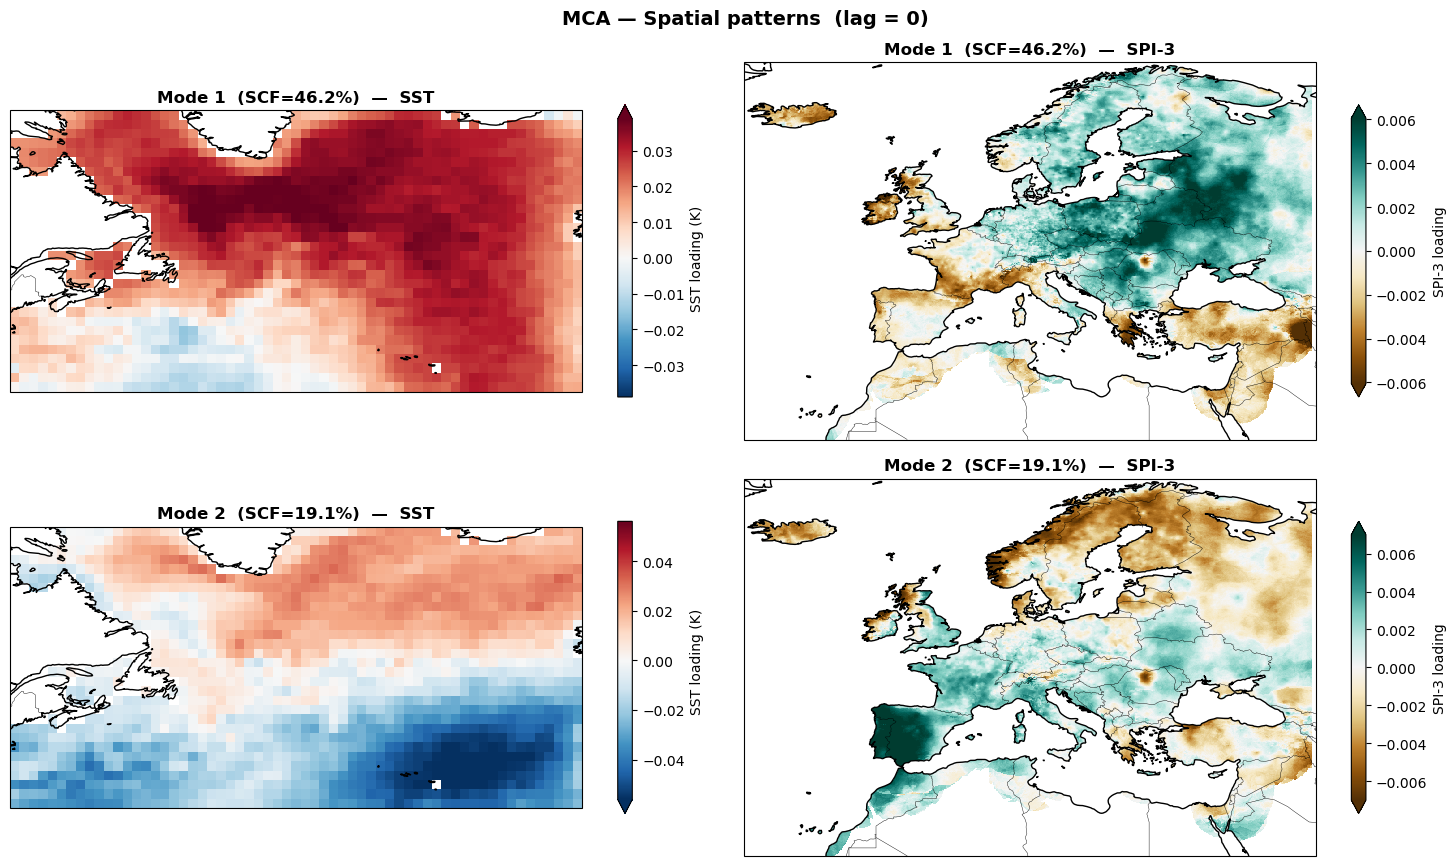

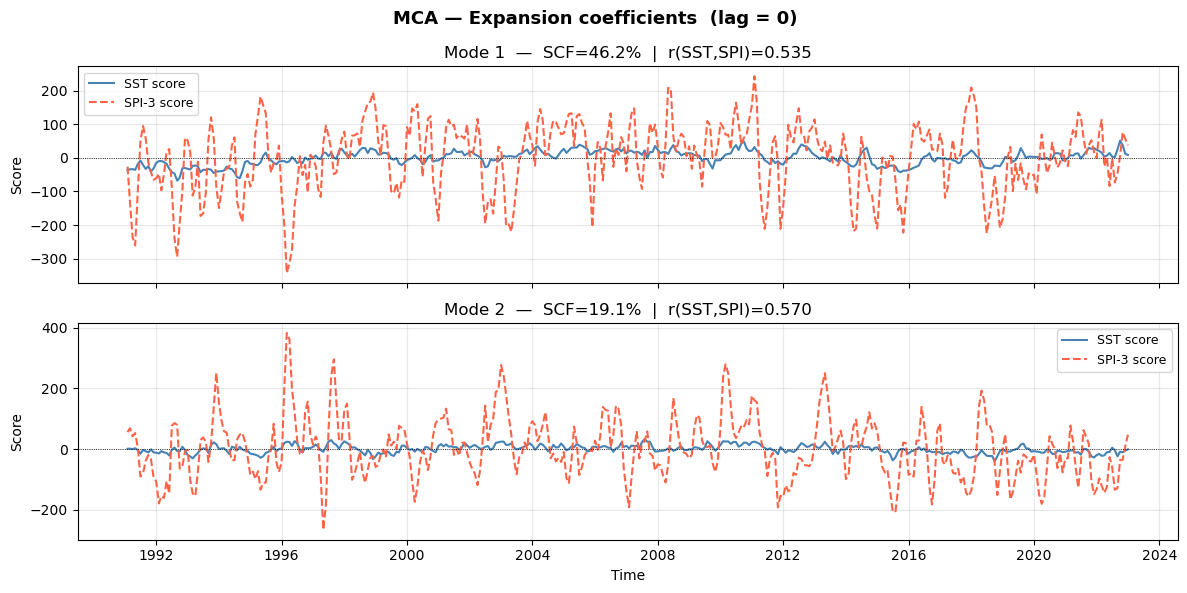

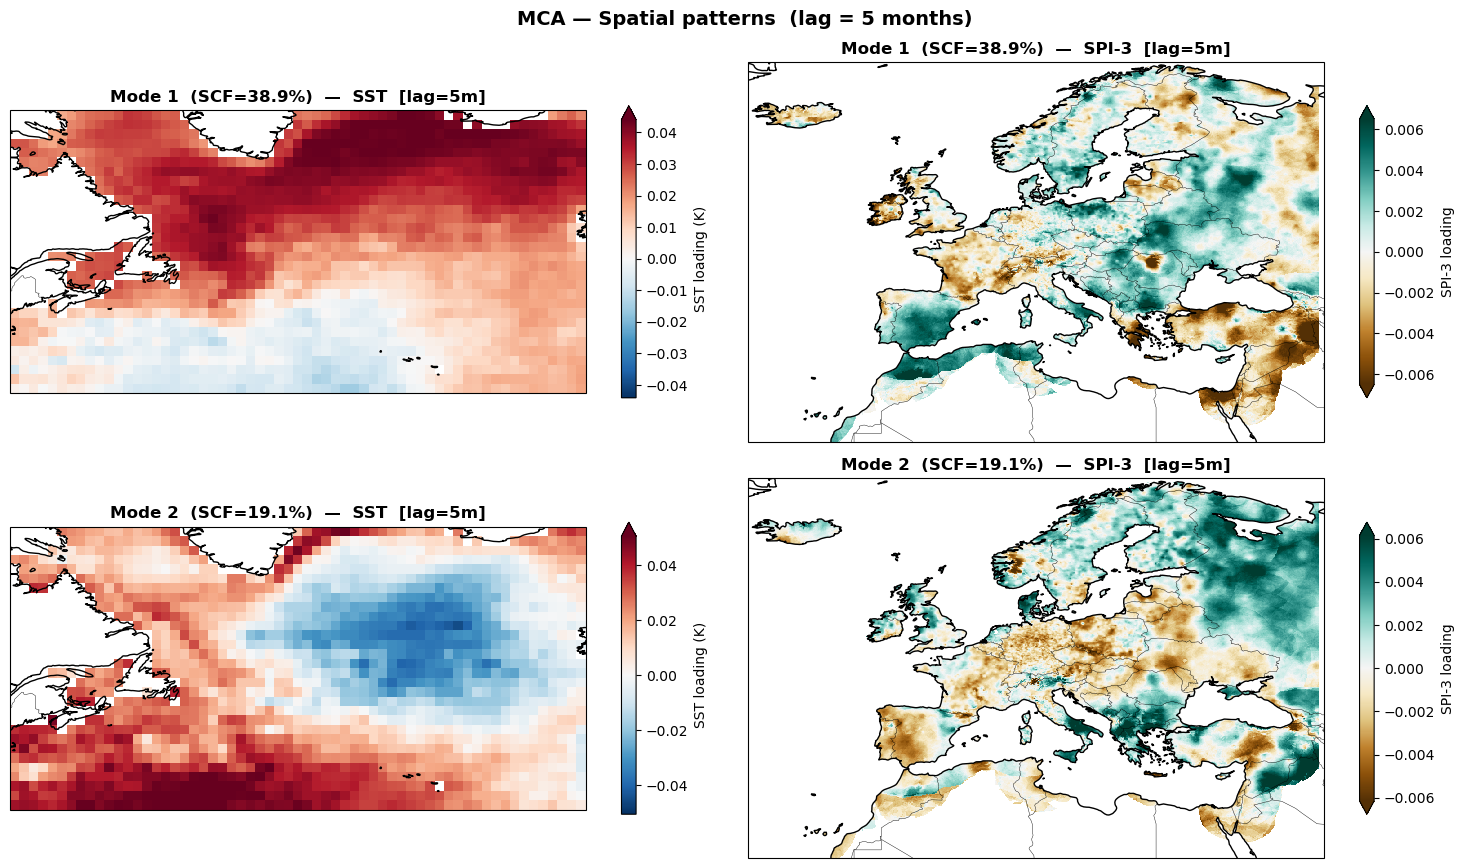

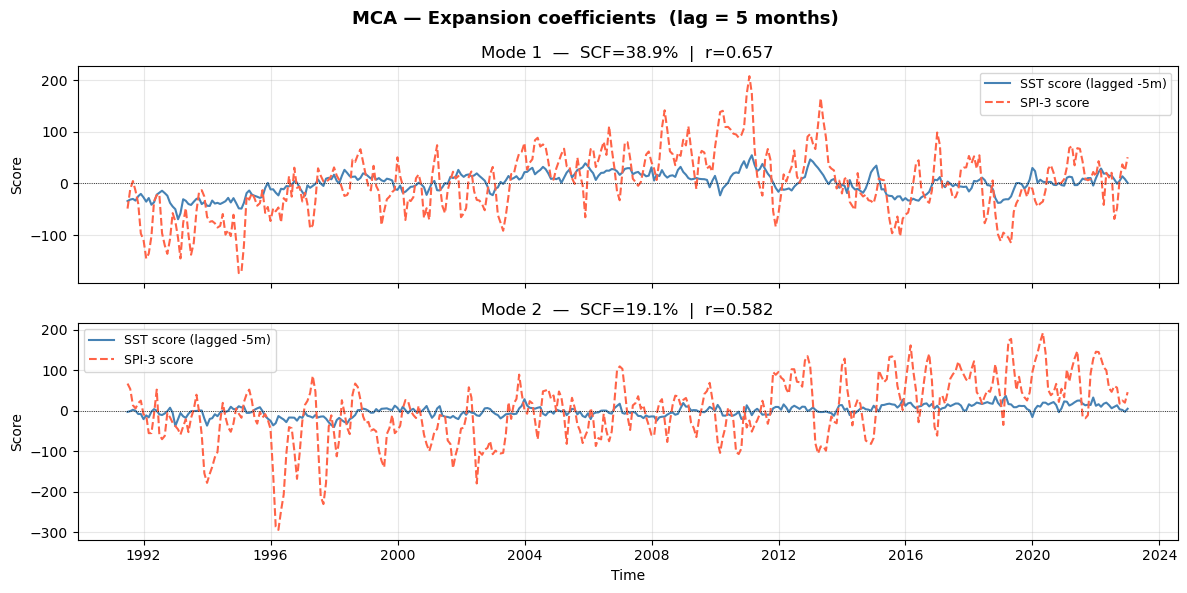

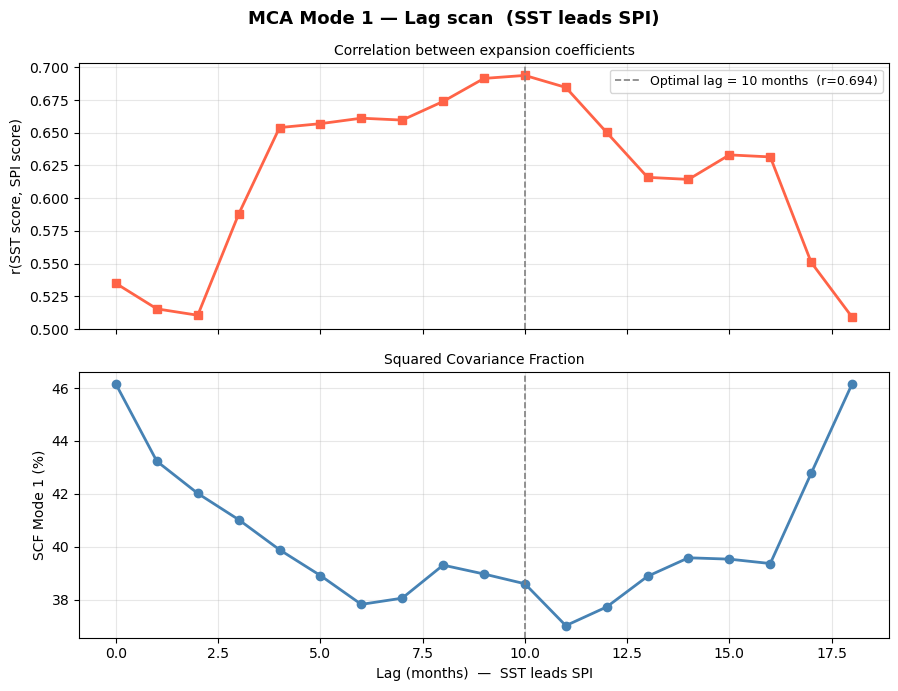


✓ Analyse MCA terminée.
  Lag optimal (Mode 1) : 10 mois  r=0.694  SCF=38.6%


In [ ]:
N_MODES = 5    # nb of MCA modes
TAU_OPT = 5    # fixed lag for the "lagged MCA" (SST leads SPI by `TAU_OPT` months)
MAX_LAG = 18   # max lag (0 → MAX_LAG include)

LAT_MIN, LAT_MAX = 35, 65    #
LON_MIN, LON_MAX = -70, -10



# anomaly
anomaly_sst = ds_sst.groupby('time.dayofyear') - climatology
anomaly_sst = anomaly_sst.sel(lat=slice(LAT_MIN, LAT_MAX),
                               lon=slice(LON_MIN, LON_MAX))
sst_da = anomaly_sst['sst']   # (time, lat, lon)

# SPI3
spi_da = ds_spi3['spo03']
if 'band' in spi_da.dims:
    spi_da = spi_da.squeeze('band').drop_vars('band')
spi_da = spi_da.sel(time=sst_da.time, method='nearest')
spi_da['time'] = sst_da['time']


def prepare_fields(sst, spi, lag=0):
    #apply lag (SST leads SPI), align in time, then handle NaNs properly for xeofs:
    #

    # returns sst_ready, spi_ready : DataArrays ready for xeofs.MCA
    #         land_mask : boolean mask (True=land/NaN) for SPI


    # lag
    if lag == 0:
        sst_out = sst.copy()
        spi_out = spi.sel(time=sst.time)
    else:
        sst_shifted = sst.shift(time=lag)               # first lag = NaN
        sst_out     = sst_shifted.isel(time=slice(lag, None))  
        spi_out     = spi.isel(time=slice(lag, None))           

    # same temporal index
    spi_out = spi_out.assign_coords(time=sst_out.time)

    # ── NaN handling ────────────────────────────────────────────────────────
    # SST : garder le masque naturel (terres → NaN)
    # → xeofs gère nativement les NaN dans le champ gauche

    # SPI : les pixels TOUJOURS NaN (océan) → remplacer par 0
    # Pixels parfois NaN (données manquantes) → interpolation temporelle
    ocean_mask = spi_out.isnull().all(dim='time')        
    land_mask  = ~ocean_mask                              

    # Remplir les NaN résiduels sur les pixels terrestres (imputation temporelle)
    spi_filled = spi_out.where(land_mask).fillna(0.0)

    print(f"  lag={lag:2d} | SST: {sst_out.shape} | SPI: {spi_filled.shape} "
          f"| pixels terrestres SPI: {int(land_mask.sum())}")

    return sst_out, spi_filled, land_mask


# Préparer à lag=0 (réutilisé pour les figures)
print("Préparation des champs (lag=0) ...")
sst_ready_0, spi_ready_0, land_mask_0 = prepare_fields(sst_da, spi_da, lag=0)


# ─────────────────────────────────────────────────────────────────────────────
# 1. MCA NON-LAGGÉE  (tau = 0)
# ─────────────────────────────────────────────────────────────────────────────
print("\n--- MCA non-laggée (tau=0) ---")

model_mca = MCA(n_modes=N_MODES, standardize=True, use_coslat=False)
model_mca.fit(sst_ready_0, spi_ready_0, dim='time')

scf                    = model_mca.squared_covariance_fraction()
scores_sst_0, scores_spi_0    = model_mca.scores()
patterns_sst_0, patterns_spi_0 = model_mca.components()

print("SCF et corrélations des expansion coefficients :")
for i, val in enumerate(scf[:N_MODES], 1):
    r = xr.corr(scores_sst_0.sel(mode=i), scores_spi_0.sel(mode=i)).values
    print(f"  Mode {i}: SCF={val.values*100:.1f}%  |  r={r:.3f}")


# ─────────────────────────────────────────────────────────────────────────────
# 2. MCA LAGGÉE FIXE  (tau = TAU_OPT)
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n--- MCA laggée (tau={TAU_OPT}) ---")

sst_ready_lag, spi_ready_lag, land_mask_lag = prepare_fields(
    sst_da, spi_da, lag=TAU_OPT
)

model_mca_lag = MCA(n_modes=N_MODES, standardize=True, use_coslat=False)
model_mca_lag.fit(sst_ready_lag, spi_ready_lag, dim='time')

scf_lag                        = model_mca_lag.squared_covariance_fraction()
scores_sst_lag, scores_spi_lag = model_mca_lag.scores()
patterns_sst_lag, patterns_spi_lag = model_mca_lag.components()

print(f"SCF (lag={TAU_OPT}) :")
for i, val in enumerate(scf_lag[:N_MODES], 1):
    r = xr.corr(scores_sst_lag.sel(mode=i), scores_spi_lag.sel(mode=i)).values
    print(f"  Mode {i}: SCF={val.values*100:.1f}%  |  r={r:.3f}")


# ─────────────────────────────────────────────────────────────────────────────
# 3. SCAN DE LAG  (0 → MAX_LAG)
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n--- Scan de lag (0 → {MAX_LAG} mois) ---")

lags_scan  = np.arange(0, MAX_LAG + 1)
corr_mode1 = []
scf_mode1  = []

for lag in lags_scan:
    sst_l, spi_l, _ = prepare_fields(sst_da, spi_da, lag=lag)

    m = MCA(n_modes=N_MODES, standardize=True, use_coslat=False)
    m.fit(sst_l, spi_l, dim='time')

    sc_sst, sc_spi = m.scores()
    scf_l          = m.squared_covariance_fraction()

    r = float(xr.corr(sc_sst.sel(mode=1), sc_spi.sel(mode=1)).values)
    corr_mode1.append(r)
    scf_mode1.append(float(scf_l[0].values) * 100)

corr_mode1 = np.array(corr_mode1)
scf_mode1  = np.array(scf_mode1)
opt_lag    = lags_scan[np.argmax(corr_mode1)]
print(f"\nLag optimal : {opt_lag} mois  (r={corr_mode1.max():.3f})")


# ─────────────────────────────────────────────────────────────────────────────
# HELPER : masquer l'océan sur un pattern SPI avant de le plotter
# ─────────────────────────────────────────────────────────────────────────────
def mask_ocean(pattern_da, land_mask):
    """Remettre NaN là où il n'y a pas de terre, pour un affichage propre."""
    return pattern_da.where(land_mask)


# ─────────────────────────────────────────────────────────────────────────────
# 4. FIGURES
# ─────────────────────────────────────────────────────────────────────────────

proj = ccrs.PlateCarree()

# ── Figure 1 : Patterns spatiaux — MCA lag=0 (modes 1 et 2) ─────────────────
fig1, axes1 = plt.subplots(
    2, 2, figsize=(15, 9),
    subplot_kw={'projection': proj}
)
fig1.suptitle('MCA — Spatial patterns  (lag = 0)', fontsize=14, fontweight='bold')

for row, mode_i in enumerate([1, 2]):
    scf_val = scf[mode_i - 1].values * 100

    # SST
    ax = axes1[row, 0]
    p  = patterns_sst_0.sel(mode=mode_i)
    v  = float(np.nanpercentile(np.abs(p.values), 98))
    p.plot(ax=ax, transform=proj, cmap='RdBu_r', vmin=-v, vmax=v,
           add_colorbar=True, cbar_kwargs={'label': 'SST loading (K)', 'shrink': 0.7})
    ax.coastlines(resolution='50m')
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.set_title(f'Mode {mode_i}  (SCF={scf_val:.1f}%)  —  SST', fontweight='bold')

    # SPI — masquer l'océan avant de plotter
    ax = axes1[row, 1]
    p  = mask_ocean(patterns_spi_0.sel(mode=mode_i), land_mask_0)
    v  = float(np.nanpercentile(np.abs(p.values), 98))
    p.plot(ax=ax, transform=proj, cmap='BrBG', vmin=-v, vmax=v,
           add_colorbar=True, cbar_kwargs={'label': 'SPI-3 loading', 'shrink': 0.7})
    ax.coastlines(resolution='50m')
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.set_title(f'Mode {mode_i}  (SCF={scf_val:.1f}%)  —  SPI-3', fontweight='bold')

plt.tight_layout()
plt.savefig('mca_patterns_lag0.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Figure 2 : Expansion coefficients — MCA lag=0 ────────────────────────────
fig2, axes2 = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fig2.suptitle('MCA — Expansion coefficients  (lag = 0)', fontsize=13, fontweight='bold')

for i, ax in enumerate(axes2, start=1):
    s   = scores_sst_0.sel(mode=i).values
    sp  = scores_spi_0.sel(mode=i).values
    r   = np.corrcoef(s, sp)[0, 1]
    scf_val = scf[i - 1].values * 100
    times   = scores_sst_0.time.values

    ax.plot(times, s,  color='steelblue', lw=1.5, label='SST score')
    ax.plot(times, sp, color='tomato',    lw=1.5, linestyle='--', label='SPI-3 score')
    ax.axhline(0, color='k', lw=0.6, ls=':')
    ax.set_ylabel('Score')
    ax.set_title(f'Mode {i}  —  SCF={scf_val:.1f}%  |  r(SST,SPI)={r:.3f}')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

axes2[-1].set_xlabel('Time')
plt.tight_layout()
plt.savefig('mca_scores_lag0.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Figure 3 : Patterns spatiaux — MCA lag=TAU_OPT (modes 1 et 2) ───────────
fig3, axes3 = plt.subplots(
    2, 2, figsize=(15, 9),
    subplot_kw={'projection': proj}
)
fig3.suptitle(f'MCA — Spatial patterns  (lag = {TAU_OPT} months)',
              fontsize=14, fontweight='bold')

for row, mode_i in enumerate([1, 2]):
    scf_val = scf_lag[mode_i - 1].values * 100

    # SST
    ax = axes3[row, 0]
    p  = patterns_sst_lag.sel(mode=mode_i)
    v  = float(np.nanpercentile(np.abs(p.values), 98))
    p.plot(ax=ax, transform=proj, cmap='RdBu_r', vmin=-v, vmax=v,
           add_colorbar=True, cbar_kwargs={'label': 'SST loading (K)', 'shrink': 0.7})
    ax.coastlines(resolution='50m')
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.set_title(f'Mode {mode_i}  (SCF={scf_val:.1f}%)  —  SST  [lag={TAU_OPT}m]',
                 fontweight='bold')

    # SPI
    ax = axes3[row, 1]
    p  = mask_ocean(patterns_spi_lag.sel(mode=mode_i), land_mask_lag)
    v  = float(np.nanpercentile(np.abs(p.values), 98))
    p.plot(ax=ax, transform=proj, cmap='BrBG', vmin=-v, vmax=v,
           add_colorbar=True, cbar_kwargs={'label': 'SPI-3 loading', 'shrink': 0.7})
    ax.coastlines(resolution='50m')
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.set_title(f'Mode {mode_i}  (SCF={scf_val:.1f}%)  —  SPI-3  [lag={TAU_OPT}m]',
                 fontweight='bold')

plt.tight_layout()
plt.savefig(f'mca_patterns_lag{TAU_OPT}.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Figure 4 : Expansion coefficients — MCA lag=TAU_OPT ─────────────────────
fig4, axes4 = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fig4.suptitle(f'MCA — Expansion coefficients  (lag = {TAU_OPT} months)',
              fontsize=13, fontweight='bold')

for i, ax in enumerate(axes4, start=1):
    s   = scores_sst_lag.sel(mode=i).values
    sp  = scores_spi_lag.sel(mode=i).values
    r   = np.corrcoef(s, sp)[0, 1]
    scf_val = scf_lag[i - 1].values * 100
    times   = scores_sst_lag.time.values

    ax.plot(times, s,  color='steelblue', lw=1.5, label=f'SST score (lagged -{TAU_OPT}m)')
    ax.plot(times, sp, color='tomato',    lw=1.5, linestyle='--', label='SPI-3 score')
    ax.axhline(0, color='k', lw=0.6, ls=':')
    ax.set_ylabel('Score')
    ax.set_title(f'Mode {i}  —  SCF={scf_val:.1f}%  |  r={r:.3f}')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

axes4[-1].set_xlabel('Time')
plt.tight_layout()
plt.savefig(f'mca_scores_lag{TAU_OPT}.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Figure 5 : Scan de lag — corrélation et SCF Mode 1 ───────────────────────
fig5, (ax_corr, ax_scf) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
fig5.suptitle('MCA Mode 1 — Lag scan  (SST leads SPI)',
              fontsize=13, fontweight='bold')

ax_corr.plot(lags_scan, corr_mode1, 's-', color='tomato', lw=2)
ax_corr.axvline(opt_lag, color='gray', ls='--', lw=1.2,
                label=f'Optimal lag = {opt_lag} months  (r={corr_mode1.max():.3f})')
ax_corr.set_ylabel('r(SST score, SPI score)')
ax_corr.set_title('Correlation between expansion coefficients', fontsize=10)
ax_corr.legend(fontsize=9)
ax_corr.grid(alpha=0.3)

ax_scf.plot(lags_scan, scf_mode1, 'o-', color='steelblue', lw=2)
ax_scf.axvline(opt_lag, color='gray', ls='--', lw=1.2)
ax_scf.set_xlabel('Lag (months)  —  SST leads SPI')
ax_scf.set_ylabel('SCF Mode 1 (%)')
ax_scf.set_title('Squared Covariance Fraction', fontsize=10)
ax_scf.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('mca_lag_scan.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Analyse MCA terminée.")
print(f"  Lag optimal (Mode 1) : {opt_lag} mois  "
      f"r={corr_mode1.max():.3f}  SCF={scf_mode1[opt_lag]:.1f}%")

## 7. Canonical Correlation Analysis (CCA)

CCA finds linear combinations of each field that are maximally correlated.
Unlike MCA which maximises covariance, CCA maximises the Pearson correlation
between the canonical variates.

A PCA pre-reduction ($n_{\text{PCA}}=20$ modes) is applied before CCA to avoid
ill-conditioning.

**Procedure** (same structure as MCA)
- In-sample CCA at lag 0
- Train/test evaluation (80%/20% chronological split)
- CCA at fixed lag $\tau = 5$ months
- Lag scan $\tau \in [0, 18]$ months

Préparation des champs (lag=0) ...
  lag= 0 | SST: (384, 30, 61) | SPI: (384, 465, 705) | pixels terre: 134351

--- CCA non-laggée (tau=0) ---
Corrélations canoniques (in-sample) :
  Mode 1: r=0.8335
  Mode 2: r=0.7662
  Mode 3: r=0.7373
  Mode 4: r=0.6850
  Mode 5: r=0.6614

--- CCA train/test (tau=0, train=80%) ---
  Train : 307 mois  |  Test : 77 mois
  Mode 1 — corr train=0.884  |  corr test=0.061

--- CCA laggée (tau=5) ---
  lag= 5 | SST: (379, 30, 61) | SPI: (379, 465, 705) | pixels terre: 134351
Corrélations canoniques (lag=5) :
  Mode 1: r=0.8291
  Mode 2: r=0.7560
  Mode 3: r=0.6581
  Mode 4: r=0.6356
  Mode 5: r=0.5525

--- Scan de lag (0 → 18 mois) ---
  lag= 0 | SST: (384, 30, 61) | SPI: (384, 465, 705) | pixels terre: 134351
  lag= 1 | SST: (383, 30, 61) | SPI: (383, 465, 705) | pixels terre: 134351
  lag= 2 | SST: (382, 30, 61) | SPI: (382, 465, 705) | pixels terre: 134351
  lag= 3 | SST: (381, 30, 61) | SPI: (381, 465, 705) | pixels terre: 134351
  lag= 4 | SST: (380, 3

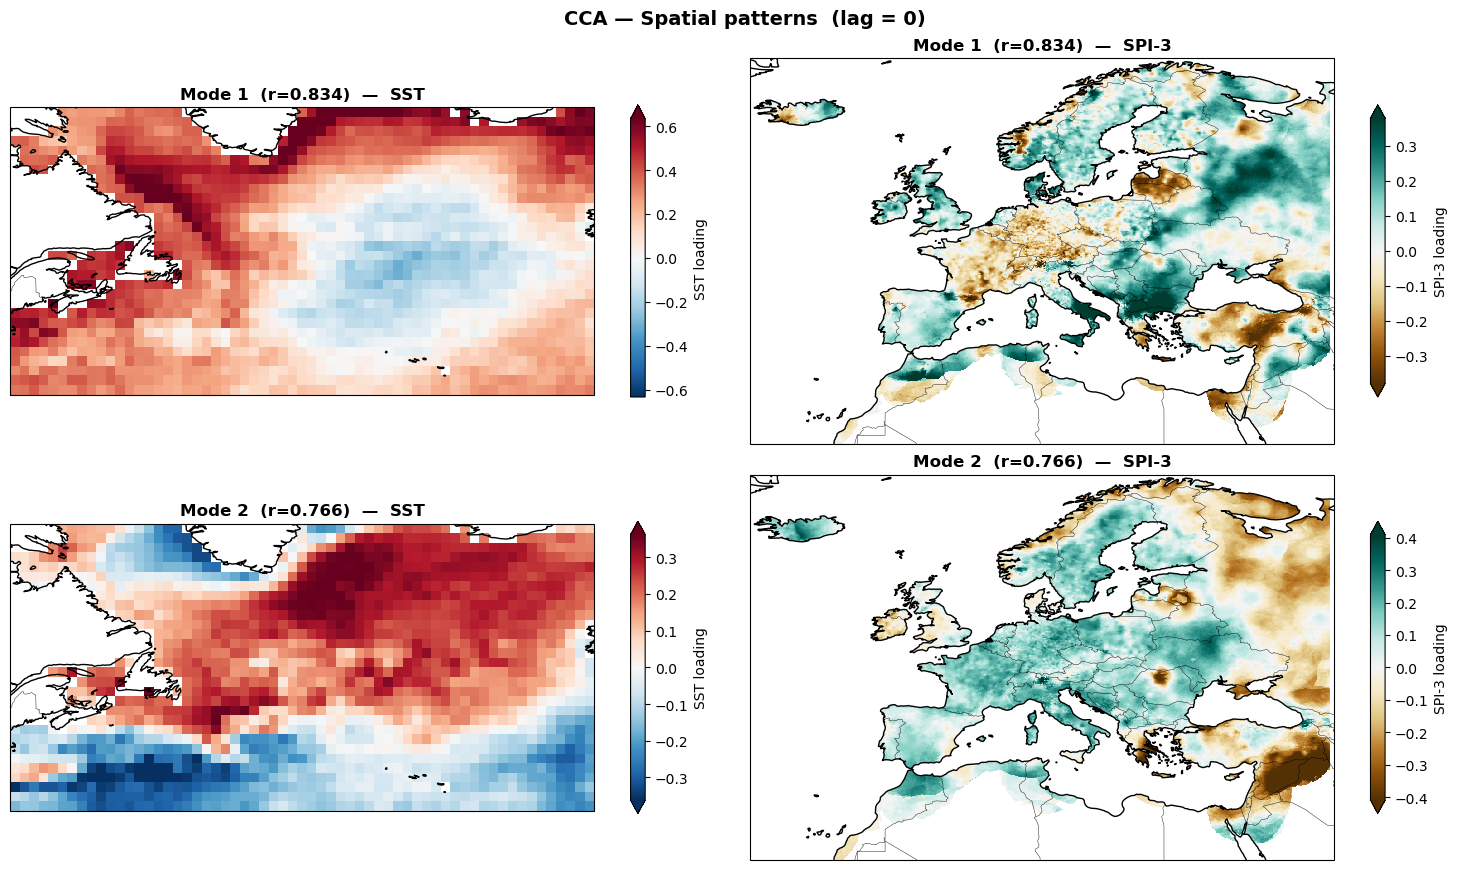

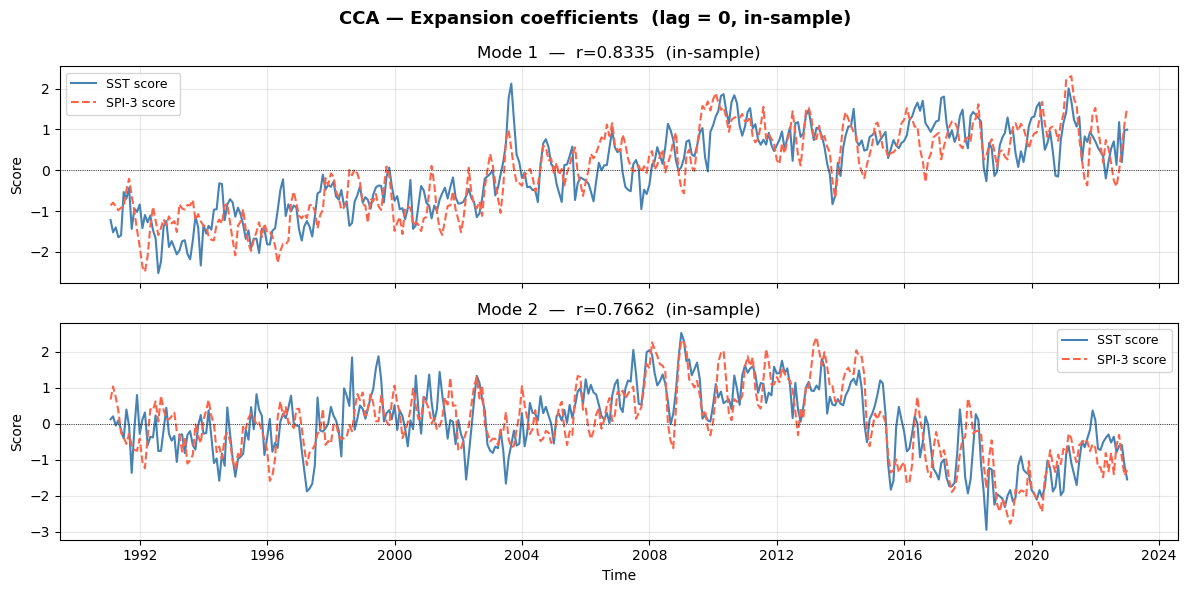

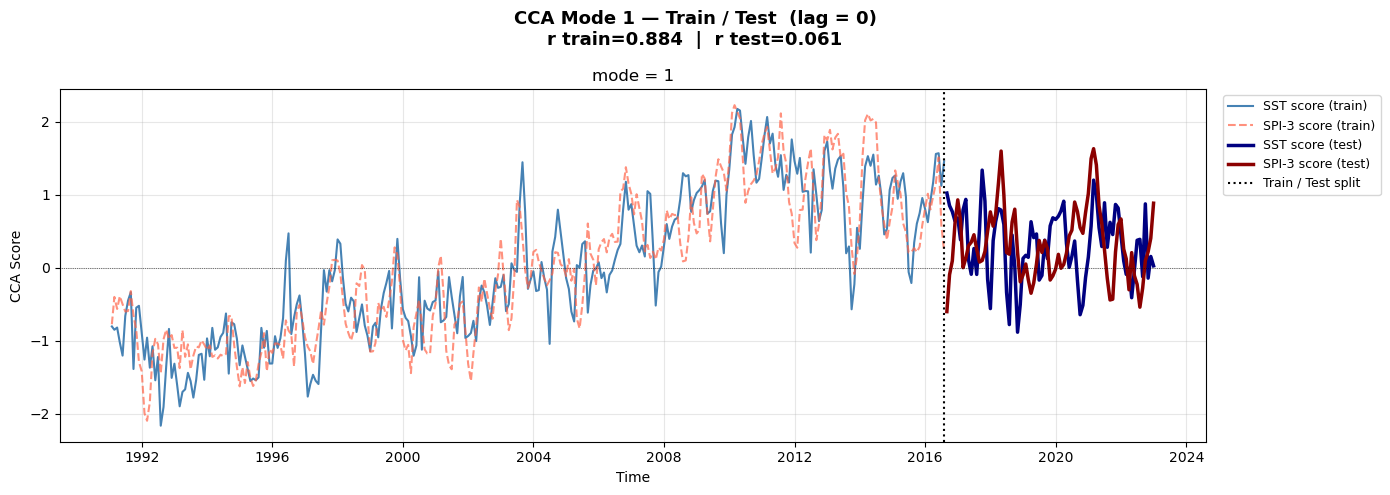

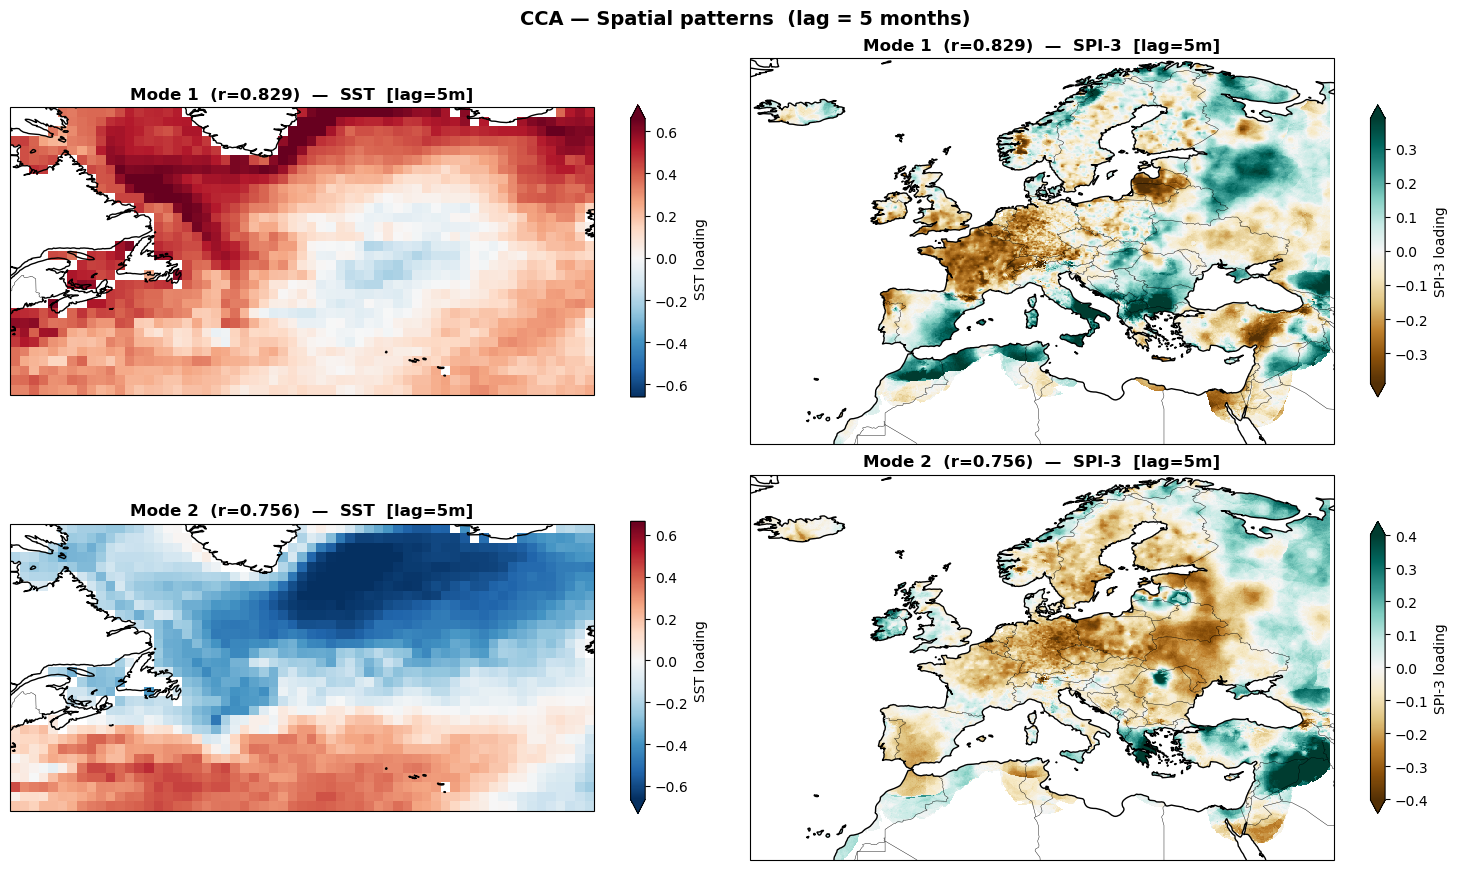

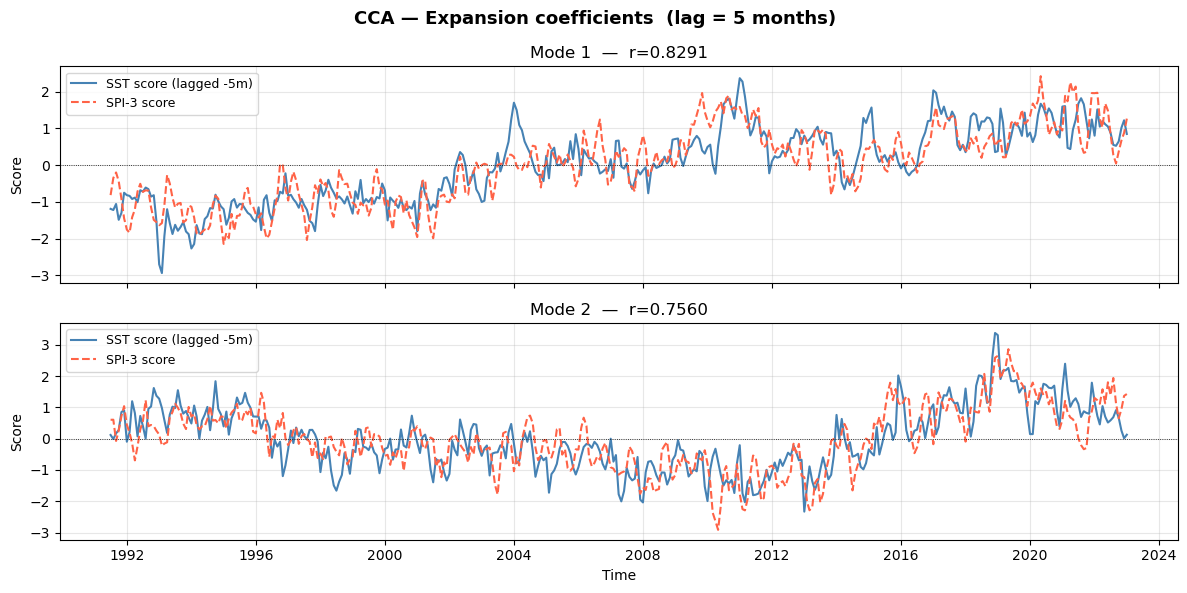

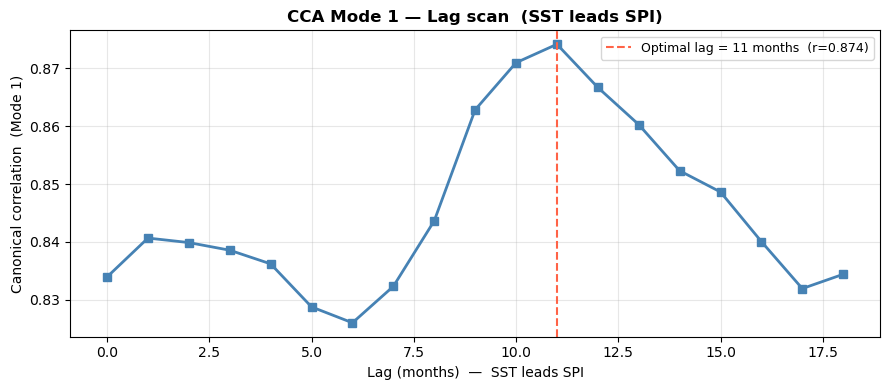


✓ Analyse CCA terminée.
  Lag optimal (Mode 1) : 11 mois  r=0.874
  Train/test  (lag=0)  : r_train=0.884  r_test=0.061


In [38]:
"""
CCA Analysis — North Atlantic SST vs European SPI-3
====================================================
Ce script suppose que les variables suivantes existent dans ton environnement :

    ds_sst       : xr.Dataset  – SST ERA5 mensuelle (1991-2022), variable 'sst'
    ds_spi3      : xr.Dataset  – SPI-3 E-OBS mensuelle, variable 'spo03'
    climatology  : xr.Dataset  – climatologie journalière de ds_sst

Structure :
    0. Préparation des champs  (même prepare_fields() que pour la MCA)
    1. CCA non-laggée   (tau = 0)  — in-sample
    2. CCA non-laggée   — évaluation train / test
    3. CCA laggée fixe  (tau = TAU_OPT)
    4. Scan de lag       (tau = 0..MAX_LAG)
    5. Figures

Même fix NaN que la MCA :
    → Les pixels SPI toujours-NaN (océan) sont mis à 0 pour conserver
      la grille régulière, puis remasqués avant l'affichage.
"""

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from xeofs.cross import CCA

# ─────────────────────────────────────────────────────────────────────────────
# PARAMÈTRES
# ─────────────────────────────────────────────────────────────────────────────
N_MODES    = 5     # modes CCA à calculer
N_PCA      = 20    # modes PCA de réduction avant CCA (évite l'ill-conditioning)
TAU_OPT    = 5     # lag fixe pour la CCA laggée (mois)
MAX_LAG    = 18    # lag max pour le scan
TRAIN_FRAC = 0.8   # fraction pour le train/test split (chronologique)

LAT_MIN, LAT_MAX = 35, 65
LON_MIN, LON_MAX = -70, -10


# ─────────────────────────────────────────────────────────────────────────────
# 0. PRÉPARATION DES CHAMPS  (identique à mca_analysis.py)
# ─────────────────────────────────────────────────────────────────────────────

# --- Anomalies SST -----------------------------------------------------------
anomaly_sst = ds_sst.groupby('time.dayofyear') - climatology
anomaly_sst = anomaly_sst.sel(lat=slice(LAT_MIN, LAT_MAX),
                               lon=slice(LON_MIN, LON_MAX))
sst_da = anomaly_sst['sst']

# --- SPI-3 -------------------------------------------------------------------
spi_da = ds_spi3['spo03']
if 'band' in spi_da.dims:
    spi_da = spi_da.squeeze('band').drop_vars('band')
spi_da = spi_da.sel(time=sst_da.time, method='nearest')
spi_da['time'] = sst_da['time']


def prepare_fields(sst, spi, lag=0):
    """
    Applique le lag (SST précède SPI de `lag` mois), aligne temporellement,
    et gère les NaN :
      - SST  : masque naturel conservé (terres → NaN, xeofs les ignore)
      - SPI  : pixels océan mis à 0  → grille régulière préservée
                pixels terrestres NaN résiduels → fillna(0)

    Retourne : sst_ready, spi_ready, land_mask
    """
    if lag == 0:
        sst_out = sst.copy()
        spi_out = spi.sel(time=sst.time)
    else:
        sst_shifted = sst.shift(time=lag)
        sst_out     = sst_shifted.isel(time=slice(lag, None))
        spi_out     = spi.isel(time=slice(lag, None))

    spi_out = spi_out.assign_coords(time=sst_out.time)

    ocean_mask = spi_out.isnull().all(dim='time')   # True = toujours NaN = océan
    land_mask  = ~ocean_mask                         # True = terre

    spi_filled = spi_out.where(land_mask).fillna(0.0)

    print(f"  lag={lag:2d} | SST: {sst_out.shape} | SPI: {spi_filled.shape} "
          f"| pixels terre: {int(land_mask.sum())}")
    return sst_out, spi_filled, land_mask


def mask_ocean(pattern_da, land_mask):
    """Remet NaN sur l'océan avant d'afficher un pattern SPI."""
    return pattern_da.where(land_mask)


# Préparer à lag=0
print("Préparation des champs (lag=0) ...")
sst_ready_0, spi_ready_0, land_mask_0 = prepare_fields(sst_da, spi_da, lag=0)


# ─────────────────────────────────────────────────────────────────────────────
# 1. CCA NON-LAGGÉE — IN-SAMPLE  (tau = 0)
# ─────────────────────────────────────────────────────────────────────────────
print("\n--- CCA non-laggée (tau=0) ---")

model_cca = CCA(
    n_modes    = N_MODES,
    standardize= True,
    use_coslat = False,
    n_pca_modes= N_PCA,
)
model_cca.fit(sst_ready_0, spi_ready_0, dim='time')

scores_sst_0, scores_spi_0       = model_cca.scores()
patterns_sst_0, patterns_spi_0   = model_cca.components()

print("Corrélations canoniques (in-sample) :")
for i in range(1, N_MODES + 1):
    r = float(xr.corr(scores_sst_0.sel(mode=i), scores_spi_0.sel(mode=i)).values)
    print(f"  Mode {i}: r={r:.4f}")


# ─────────────────────────────────────────────────────────────────────────────
# 2. CCA NON-LAGGÉE — TRAIN / TEST  (tau = 0)
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n--- CCA train/test (tau=0, train={int(TRAIN_FRAC*100)}%) ---")

n_total  = sst_ready_0.sizes['time']
n_train  = int(n_total * TRAIN_FRAC)

sst_train = sst_ready_0.isel(time=slice(None, n_train))
sst_test  = sst_ready_0.isel(time=slice(n_train, None))
spi_train = spi_ready_0.isel(time=slice(None, n_train))
spi_test  = spi_ready_0.isel(time=slice(n_train, None))

print(f"  Train : {n_train} mois  |  Test : {n_total - n_train} mois")

model_cca_tt = CCA(
    n_modes    = N_MODES,
    standardize= True,
    use_coslat = False,
    n_pca_modes= N_PCA,
)
model_cca_tt.fit(sst_train, spi_train, dim='time')

# Scores train
scores_train_sst, scores_train_spi = model_cca_tt.scores()

# Scores test — projection sur le modèle entraîné
scores_test_sst, scores_test_spi = model_cca_tt.transform(sst_test, spi_test)

corr_train = float(xr.corr(
    scores_train_sst.sel(mode=1), scores_train_spi.sel(mode=1)
).values)
corr_test = float(xr.corr(
    scores_test_sst.sel(mode=1), scores_test_spi.sel(mode=1)
).values)

print(f"  Mode 1 — corr train={corr_train:.3f}  |  corr test={corr_test:.3f}")


# ─────────────────────────────────────────────────────────────────────────────
# 3. CCA LAGGÉE FIXE  (tau = TAU_OPT)
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n--- CCA laggée (tau={TAU_OPT}) ---")

sst_ready_lag, spi_ready_lag, land_mask_lag = prepare_fields(
    sst_da, spi_da, lag=TAU_OPT
)

model_cca_lag = CCA(
    n_modes    = N_MODES,
    standardize= True,
    use_coslat = False,
    n_pca_modes= N_PCA,
)
model_cca_lag.fit(sst_ready_lag, spi_ready_lag, dim='time')

scores_sst_lag, scores_spi_lag     = model_cca_lag.scores()
patterns_sst_lag, patterns_spi_lag = model_cca_lag.components()

print(f"Corrélations canoniques (lag={TAU_OPT}) :")
for i in range(1, N_MODES + 1):
    r = float(xr.corr(scores_sst_lag.sel(mode=i), scores_spi_lag.sel(mode=i)).values)
    print(f"  Mode {i}: r={r:.4f}")


# ─────────────────────────────────────────────────────────────────────────────
# 4. SCAN DE LAG  (0 → MAX_LAG)
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n--- Scan de lag (0 → {MAX_LAG} mois) ---")

lags_scan  = np.arange(0, MAX_LAG + 1)
corr_scan  = []   # corrélation canonique Mode 1

for lag in lags_scan:
    sst_l, spi_l, _ = prepare_fields(sst_da, spi_da, lag=lag)

    m = CCA(n_modes=N_MODES, standardize=True,
            use_coslat=False, n_pca_modes=N_PCA)
    m.fit(sst_l, spi_l, dim='time')

    sc_sst, sc_spi = m.scores()
    r = float(xr.corr(sc_sst.sel(mode=1), sc_spi.sel(mode=1)).values)
    corr_scan.append(r)

corr_scan = np.array(corr_scan)
opt_lag   = lags_scan[np.argmax(corr_scan)]
print(f"\nLag optimal : {opt_lag} mois  (r={corr_scan.max():.3f})")


# ─────────────────────────────────────────────────────────────────────────────
# 5. FIGURES
# ─────────────────────────────────────────────────────────────────────────────

proj = ccrs.PlateCarree()

# ── Figure 1 : Patterns spatiaux — CCA lag=0 (modes 1 et 2) ─────────────────
fig1, axes1 = plt.subplots(
    2, 2, figsize=(15, 9),
    subplot_kw={'projection': proj}
)
fig1.suptitle('CCA — Spatial patterns  (lag = 0)', fontsize=14, fontweight='bold')

for row, mode_i in enumerate([1, 2]):
    r_val = float(xr.corr(
        scores_sst_0.sel(mode=mode_i), scores_spi_0.sel(mode=mode_i)
    ).values)

    # SST
    ax = axes1[row, 0]
    p  = patterns_sst_0.sel(mode=mode_i)
    v  = float(np.nanpercentile(np.abs(p.values), 98))
    p.plot(ax=ax, transform=proj, cmap='RdBu_r', vmin=-v, vmax=v,
           add_colorbar=True, cbar_kwargs={'label': 'SST loading', 'shrink': 0.7})
    ax.coastlines(resolution='50m')
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.set_title(f'Mode {mode_i}  (r={r_val:.3f})  —  SST', fontweight='bold')

    # SPI — masquer l'océan
    ax = axes1[row, 1]
    p  = mask_ocean(patterns_spi_0.sel(mode=mode_i), land_mask_0)
    v  = float(np.nanpercentile(np.abs(p.values), 98))
    p.plot(ax=ax, transform=proj, cmap='BrBG', vmin=-v, vmax=v,
           add_colorbar=True, cbar_kwargs={'label': 'SPI-3 loading', 'shrink': 0.7})
    ax.coastlines(resolution='50m')
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.set_title(f'Mode {mode_i}  (r={r_val:.3f})  —  SPI-3', fontweight='bold')

plt.tight_layout()
plt.savefig('cca_patterns_lag0.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Figure 2 : Expansion coefficients — CCA lag=0, in-sample ─────────────────
fig2, axes2 = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fig2.suptitle('CCA — Expansion coefficients  (lag = 0, in-sample)',
              fontsize=13, fontweight='bold')

for i, ax in enumerate(axes2, start=1):
    s   = scores_sst_0.sel(mode=i).values
    sp  = scores_spi_0.sel(mode=i).values
    r   = np.corrcoef(s, sp)[0, 1]
    times = scores_sst_0.time.values

    ax.plot(times, s,  color='steelblue', lw=1.5, label='SST score')
    ax.plot(times, sp, color='tomato',    lw=1.5, linestyle='--', label='SPI-3 score')
    ax.axhline(0, color='k', lw=0.6, ls=':')
    ax.set_ylabel('Score')
    ax.set_title(f'Mode {i}  —  r={r:.4f}  (in-sample)')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

axes2[-1].set_xlabel('Time')
plt.tight_layout()
plt.savefig('cca_scores_lag0_insample.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Figure 3 : Train / test — CCA lag=0, Mode 1 ──────────────────────────────
split_date = sst_train.time.values[-1]

fig3, ax3 = plt.subplots(figsize=(14, 5))
fig3.suptitle(f'CCA Mode 1 — Train / Test  (lag = 0)\n'
              f'r train={corr_train:.3f}  |  r test={corr_test:.3f}',
              fontsize=13, fontweight='bold')

scores_train_sst.sel(mode=1).plot(ax=ax3, color='steelblue', lw=1.5,
                                  label='SST score (train)')
scores_train_spi.sel(mode=1).plot(ax=ax3, color='tomato', lw=1.5,
                                  linestyle='--', alpha=0.7,
                                  label='SPI-3 score (train)')
scores_test_sst.sel(mode=1).plot(ax=ax3, color='navy', lw=2.5,
                                 label='SST score (test)')
scores_test_spi.sel(mode=1).plot(ax=ax3, color='darkred', lw=2.5,
                                 label='SPI-3 score (test)')

ax3.axvline(x=split_date, color='black', linestyle=':', lw=1.5,
            label='Train / Test split')
ax3.axhline(0, color='k', lw=0.5, ls=':')
ax3.set_xlabel('Time')
ax3.set_ylabel('CCA Score')
ax3.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9)
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cca_train_test.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Figure 4 : Patterns spatiaux — CCA lag=TAU_OPT (modes 1 et 2) ───────────
fig4, axes4 = plt.subplots(
    2, 2, figsize=(15, 9),
    subplot_kw={'projection': proj}
)
fig4.suptitle(f'CCA — Spatial patterns  (lag = {TAU_OPT} months)',
              fontsize=14, fontweight='bold')

for row, mode_i in enumerate([1, 2]):
    r_val = float(xr.corr(
        scores_sst_lag.sel(mode=mode_i), scores_spi_lag.sel(mode=mode_i)
    ).values)

    # SST
    ax = axes4[row, 0]
    p  = patterns_sst_lag.sel(mode=mode_i)
    v  = float(np.nanpercentile(np.abs(p.values), 98))
    p.plot(ax=ax, transform=proj, cmap='RdBu_r', vmin=-v, vmax=v,
           add_colorbar=True, cbar_kwargs={'label': 'SST loading', 'shrink': 0.7})
    ax.coastlines(resolution='50m')
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.set_title(f'Mode {mode_i}  (r={r_val:.3f})  —  SST  [lag={TAU_OPT}m]',
                 fontweight='bold')

    # SPI
    ax = axes4[row, 1]
    p  = mask_ocean(patterns_spi_lag.sel(mode=mode_i), land_mask_lag)
    v  = float(np.nanpercentile(np.abs(p.values), 98))
    p.plot(ax=ax, transform=proj, cmap='BrBG', vmin=-v, vmax=v,
           add_colorbar=True, cbar_kwargs={'label': 'SPI-3 loading', 'shrink': 0.7})
    ax.coastlines(resolution='50m')
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.set_title(f'Mode {mode_i}  (r={r_val:.3f})  —  SPI-3  [lag={TAU_OPT}m]',
                 fontweight='bold')

plt.tight_layout()
plt.savefig(f'cca_patterns_lag{TAU_OPT}.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Figure 5 : Expansion coefficients — CCA lag=TAU_OPT ─────────────────────
fig5, axes5 = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fig5.suptitle(f'CCA — Expansion coefficients  (lag = {TAU_OPT} months)',
              fontsize=13, fontweight='bold')

for i, ax in enumerate(axes5, start=1):
    s   = scores_sst_lag.sel(mode=i).values
    sp  = scores_spi_lag.sel(mode=i).values
    r   = np.corrcoef(s, sp)[0, 1]
    times = scores_sst_lag.time.values

    ax.plot(times, s,  color='steelblue', lw=1.5,
            label=f'SST score (lagged -{TAU_OPT}m)')
    ax.plot(times, sp, color='tomato',    lw=1.5, linestyle='--',
            label='SPI-3 score')
    ax.axhline(0, color='k', lw=0.6, ls=':')
    ax.set_ylabel('Score')
    ax.set_title(f'Mode {i}  —  r={r:.4f}')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

axes5[-1].set_xlabel('Time')
plt.tight_layout()
plt.savefig(f'cca_scores_lag{TAU_OPT}.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Figure 6 : Scan de lag — corrélation canonique Mode 1 ────────────────────
fig6, ax6 = plt.subplots(figsize=(9, 4))
ax6.plot(lags_scan, corr_scan, 's-', color='steelblue', lw=2, markersize=6)
ax6.axvline(opt_lag, color='tomato', ls='--', lw=1.5,
            label=f'Optimal lag = {opt_lag} months  (r={corr_scan.max():.3f})')
ax6.set_xlabel('Lag (months)  —  SST leads SPI')
ax6.set_ylabel('Canonical correlation  (Mode 1)')
ax6.set_title('CCA Mode 1 — Lag scan  (SST leads SPI)', fontweight='bold')
ax6.legend(fontsize=9)
ax6.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cca_lag_scan.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Analyse CCA terminée.")
print(f"  Lag optimal (Mode 1) : {opt_lag} mois  r={corr_scan.max():.3f}")
print(f"  Train/test  (lag=0)  : r_train={corr_train:.3f}  r_test={corr_test:.3f}")

## (Optional) Model generalisation to multiple regions / lead times